<a href="https://colab.research.google.com/github/peterbmob/CH-PFC/blob/main/combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
# --- 1) Imports & environment ---
import os, sys, numpy as np, matplotlib.pyplot as plt
# Make 'src' importable (adjust if needed)
if 'src' not in map(str.lower, os.listdir('.')):
    # If running in hosted env, you may need to upload or mount your repo so 'src' exists.
    pass
sys.path.append('src')

# Your project utilities
try:
    from chpfc import (
        Params, init_fields, pfc_relax_stable,
        init_poly_voronoi_simple
    )
except Exception as e:
    raise ImportError("Could not import from src/chpfc.py. Ensure your repository layout is available.") from e

# Optional pretty field plots
try:
    from plotting import plot_fields
    HAVE_PLOT_FIELDS = True
except Exception:
    HAVE_PLOT_FIELDS = False
    def plot_fields(c, psi, mask, title_prefix=''):
        fig, axs = plt.subplots(1, 3, figsize=(10, 3.2))
        im0 = axs[0].imshow(c.T, origin='lower', cmap='viridis', vmin=0, vmax=1)
        axs[0].set_title(f'{title_prefix} c')
        plt.colorbar(im0, ax=axs[0], fraction=0.046)
        im1 = axs[1].imshow(psi.T, origin='lower', cmap='coolwarm')
        axs[1].set_title('psi')
        plt.colorbar(im1, ax=axs[1], fraction=0.046)
        im2 = axs[2].imshow(mask.T, origin='lower', cmap='gray')
        axs[2].set_title('mask')
        plt.tight_layout()
        return fig, axs


In [47]:
# --- 2) Spectral CH helper (FFT cache + stable step) ---
from numpy.fft import fftn, ifftn, fftfreq

class FFTCache:
    def __init__(self, nx, ny, Lx, Ly):
        kx = 2*np.pi*fftfreq(nx, d=Lx/nx)
        ky = 2*np.pi*fftfreq(ny, d=Ly/ny)
        self.KX, self.KY = np.meshgrid(kx, ky, indexing='ij')
        self.K2 = self.KX**2 + self.KY**2
        self.K2[0, 0] = 1e-30  # avoid divide by zero

def build_fft_cache_from_params(p):
    nx, ny = int(p.nx), int(p.ny)
    Lx, Ly = nx*float(p.dx), ny*float(p.dx)
    return FFTCache(nx, ny, Lx, Ly)

def laplace_fft(f, cache):
    return np.real(ifftn(-cache.K2 * fftn(f)))

def div_of_M_grad_mu_fft(M, mu, cache):
    muk = fftn(mu)
    mux = np.real(ifftn(1j * cache.KX * muk))
    muy = np.real(ifftn(1j * cache.KY * muk))
    jx = M * mux
    jy = M * muy
    return np.real(ifftn(1j * cache.KX * fftn(jx) + 1j * cache.KY * fftn(jy)))

def mu_chem_regular_solution(c, RT, Om, eps=1e-12):
    ce = np.clip(c, eps, 1.0 - eps)
    return RT*(np.log(ce) - np.log(1.0 - ce)) + Om*(1.0 - 2.0*ce)

def ch_step_spectral(
    c, psi, p, cache, *, dt=1e-3, n_sub=1, mask=None,
    mobility=1.0, kappa_iso=None, mu_coupling=None, reservoir_value=1.0
):
    c = np.asarray(c, dtype=np.float64, order='C').copy()
    if kappa_iso is None:
        kappa_iso = float(p.kappa)
    for _ in range(n_sub):
        mu = mu_chem_regular_solution(c, float(p.RT), float(p.Om))
        mu -= laplace_fft(c, cache)
        if callable(mu_coupling):
            mu += mu_coupling(c, psi)
        if mask is None:
            Mc = mobility * c * (1.0 - c)
        else:
            Mc = mobility * mask.astype(float) * c * (1.0 - c)
        div_term = div_of_M_grad_mu_fft(Mc, mu, cache)
        K2 = cache.K2
        Ak = 1.0 + dt * (mobility * K2 + kappa_iso * mobility * K2**2)
        rhs = c + dt * div_term
        c = np.real(ifftn(fftn(rhs) / Ak))
        if mask is not None:
            c[~mask] = reservoir_value
        np.clip(c, 1e-8, 1.0 - 1e-8, out=c)
        if not np.isfinite(c).all():
            raise FloatingPointError('CH spectral step produced NaN/Inf; lower dt or mobility.')
    return c

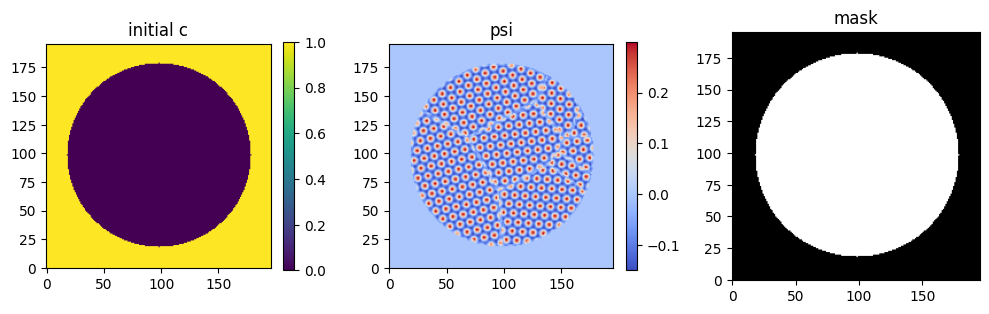

In [50]:
# --- Build params & fields ---
p = Params(nx=196, ny=196, r_electrode=80,
           r_inside=-0.20, xi=0.1, gamma=1.2,
           kappa=4.0, RT=1.0, Om=2.0)

c, psi, r_field, mask = init_fields(p, seed=0)
fft_cache = build_fft_cache_from_params(p)

# Enforce intended initial condition: FePO4 inside (c≈0), Li reservoir outside (c=1)
c = np.where(mask, 0.0, 1.0).astype(float)

# Optional: seed psi with a simple polycrystal to avoid grid locking
psi0, labels, seeds, thetas = init_poly_voronoi_simple(
    p, mask, n_grains=8, amp=0.30, k=0.8, band_px=1, seed=4
)
# Short ψ warm-up at fixed c
#psi = pfc_relax_stable(psi0, c, r_field, p, mask=mask,
#                       n_steps=400, dt0=1e-5, dt_max=1e-4,
#                       psi_clip=1.8, enforce_amorphous=False, verbose_every=200)
psi = pfc_step_spectral(psi=psi0, c=c, r_field=r_field, p=p, cache=fft_cache,
                                  mask=mask, dt=pfc_spectral_dt, psi_clip=1.8)
_ = plot_fields(c, psi, mask, title_prefix='initial')
plt.show()

[step 0001] max|psi|=0.166, <c_in>=0.3267


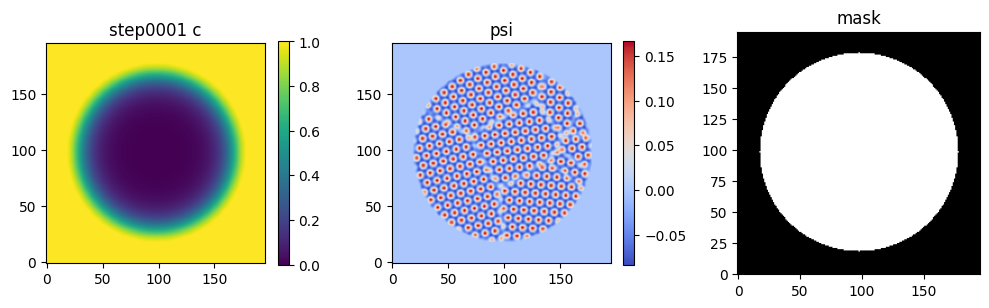

[step 0025] max|psi|=0.155, <c_in>=0.3428


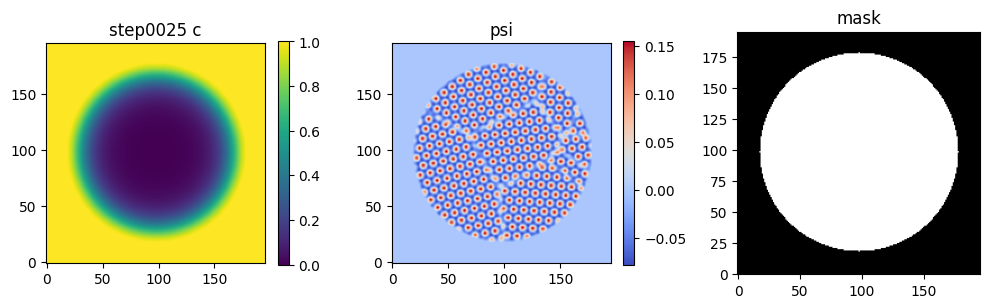

[step 0050] max|psi|=0.144, <c_in>=0.3584


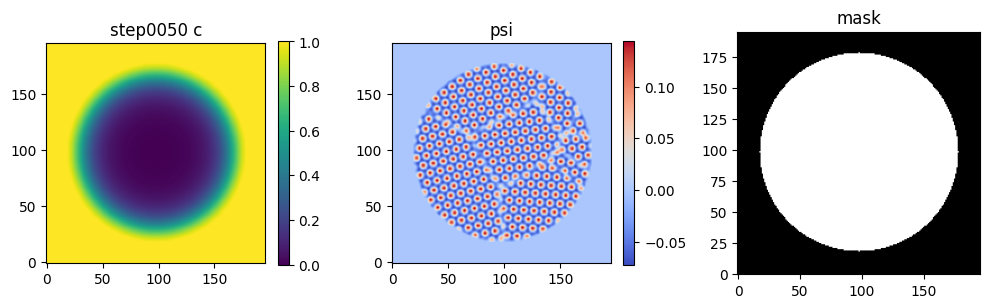

[step 0075] max|psi|=0.134, <c_in>=0.3732


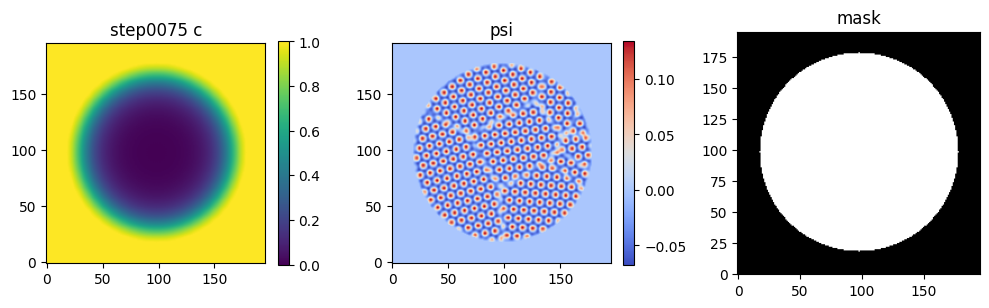

[step 0100] max|psi|=0.125, <c_in>=0.3872


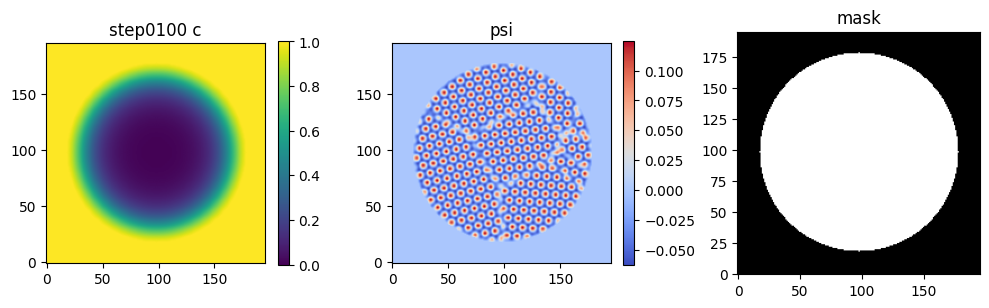

[step 0125] max|psi|=0.116, <c_in>=0.4005


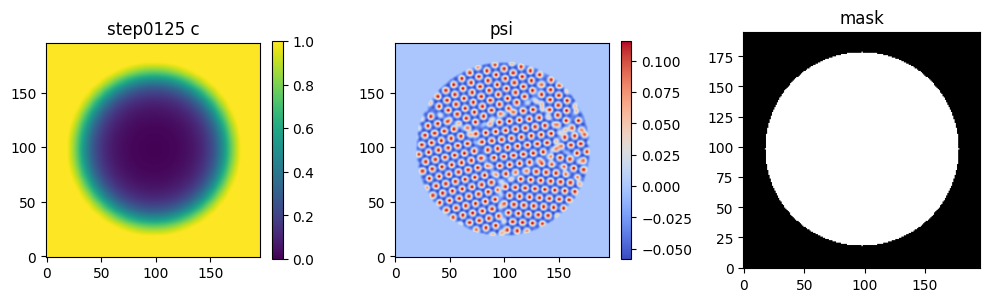

[step 0150] max|psi|=0.108, <c_in>=0.4133


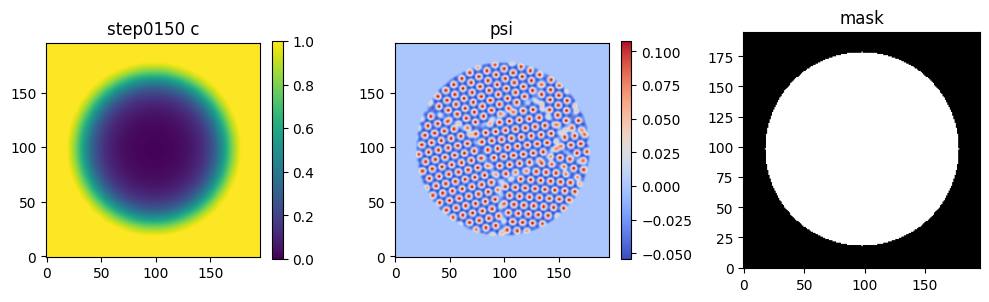

[step 0175] max|psi|=0.100, <c_in>=0.4254


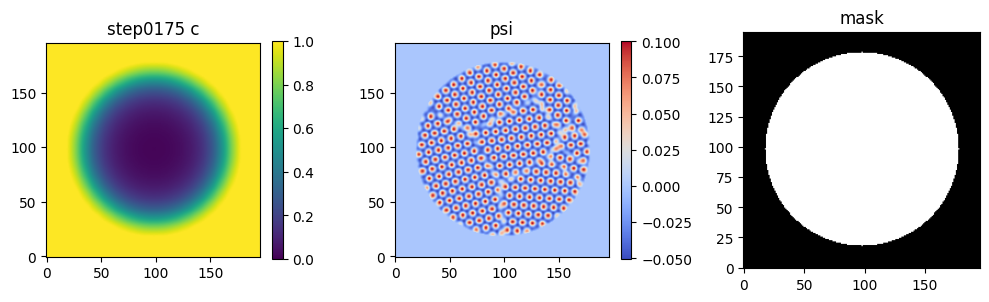

[step 0200] max|psi|=0.093, <c_in>=0.4371


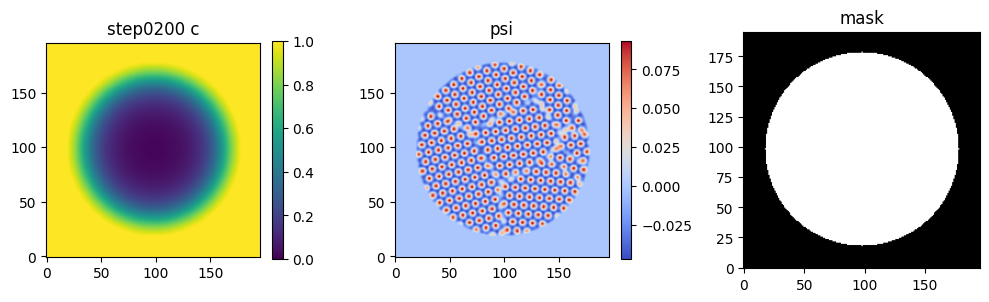

[step 0225] max|psi|=0.087, <c_in>=0.4484


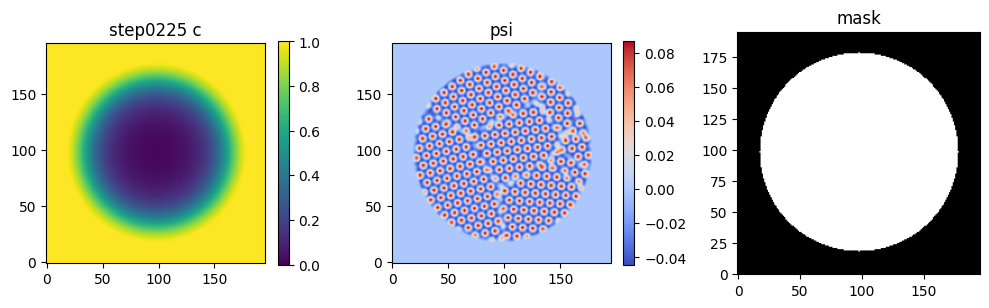

[step 0250] max|psi|=0.081, <c_in>=0.4592


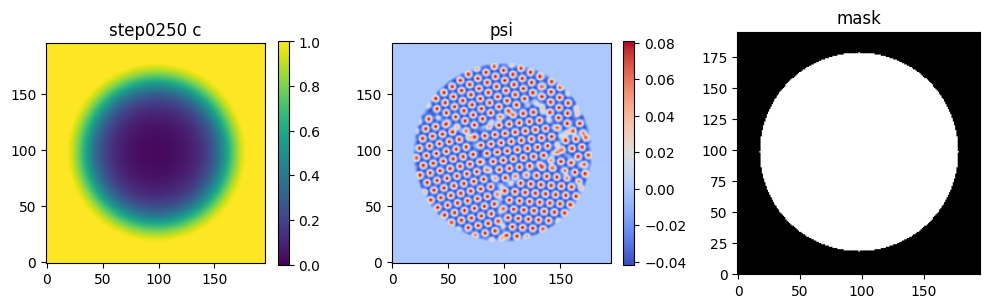

[step 0275] max|psi|=0.075, <c_in>=0.4697


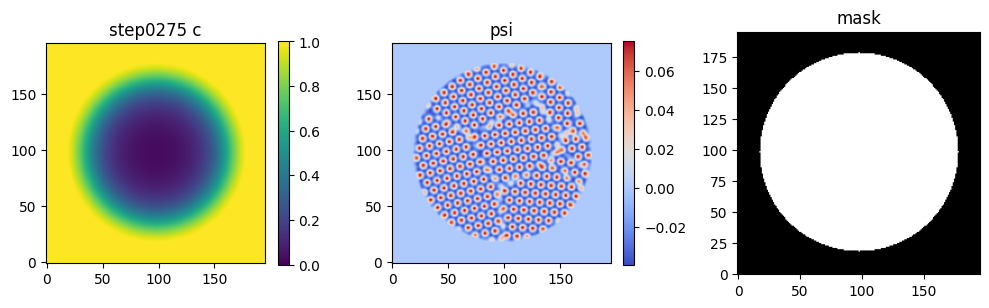

[step 0300] max|psi|=0.070, <c_in>=0.4798


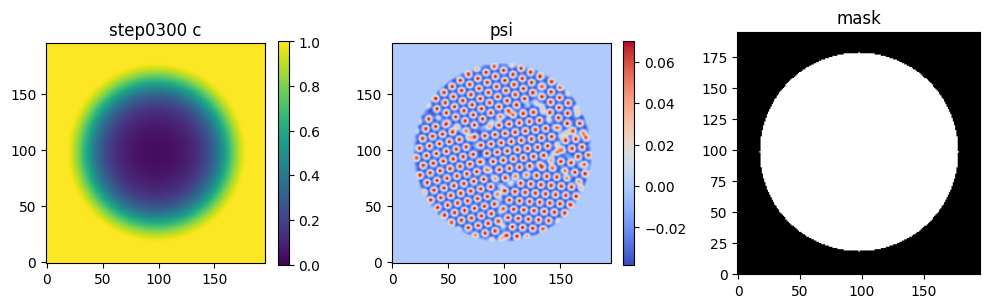

[step 0325] max|psi|=0.065, <c_in>=0.4896


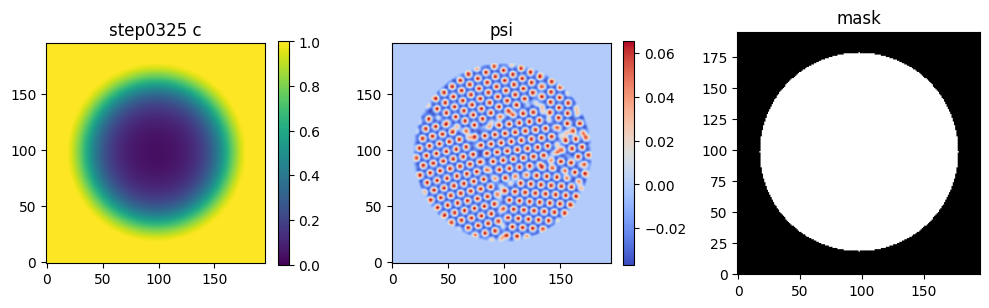

[step 0350] max|psi|=0.061, <c_in>=0.4991


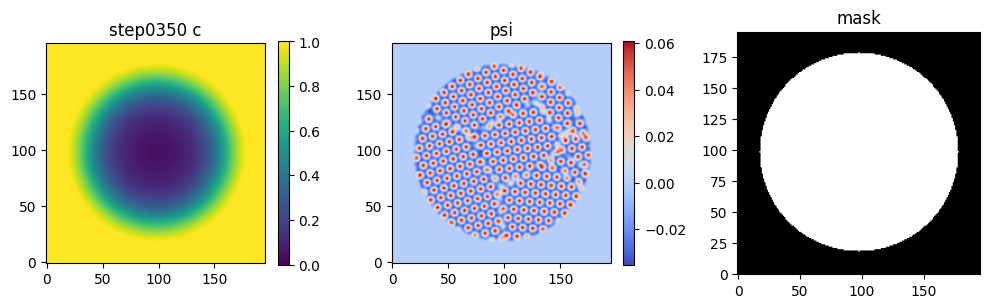

[step 0375] max|psi|=0.057, <c_in>=0.5083


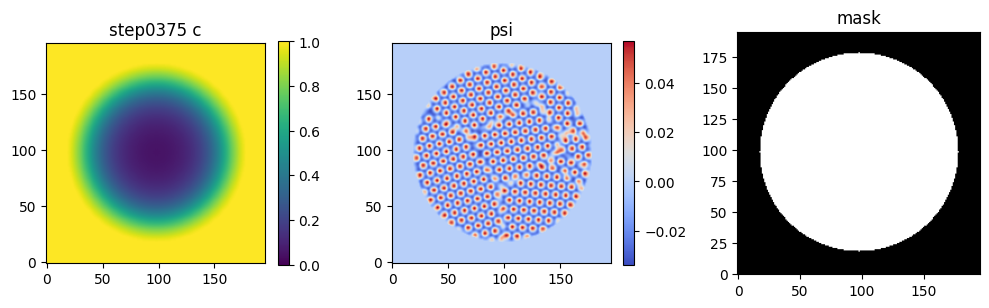

[step 0400] max|psi|=0.054, <c_in>=0.5173


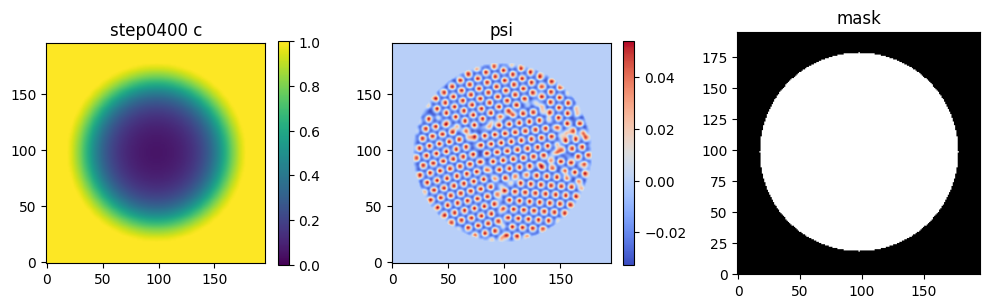

[step 0425] max|psi|=0.051, <c_in>=0.5260


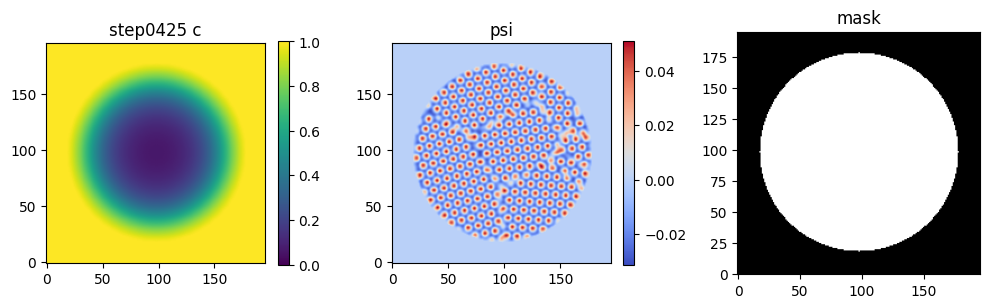

[step 0450] max|psi|=0.048, <c_in>=0.5345


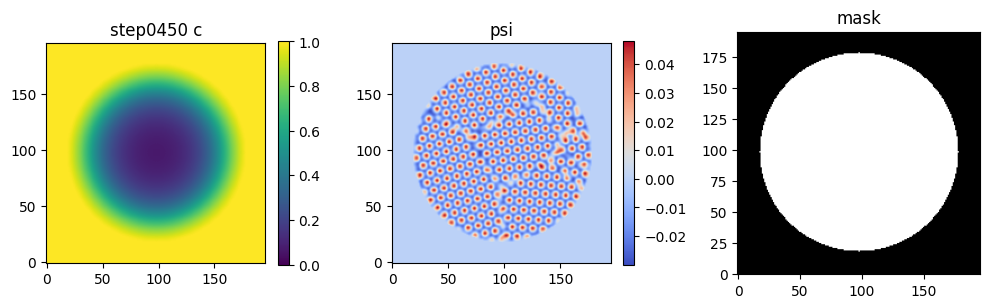

[step 0475] max|psi|=0.045, <c_in>=0.5427


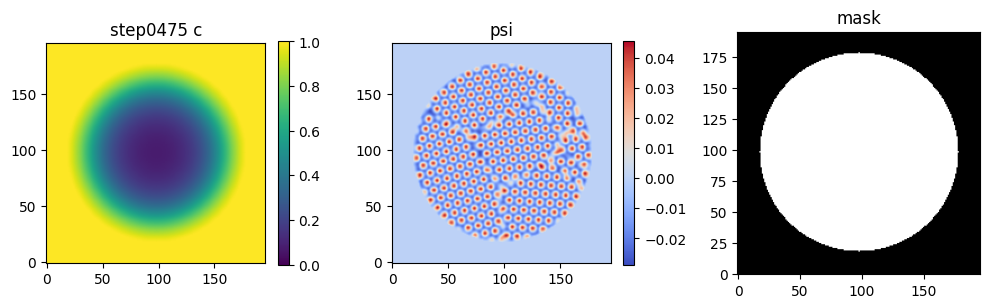

[step 0500] max|psi|=0.043, <c_in>=0.5508


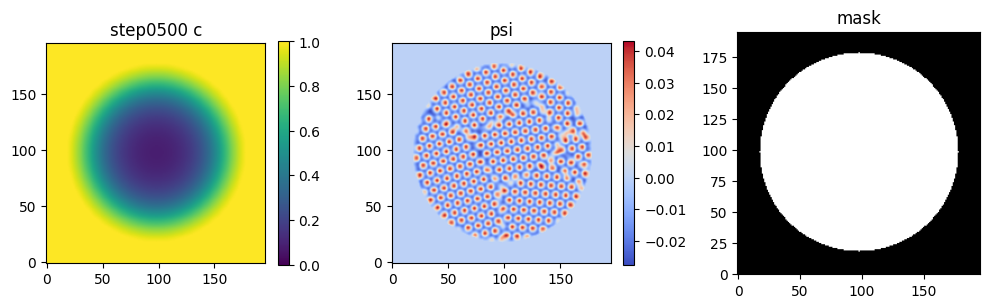

[step 0525] max|psi|=0.041, <c_in>=0.5586


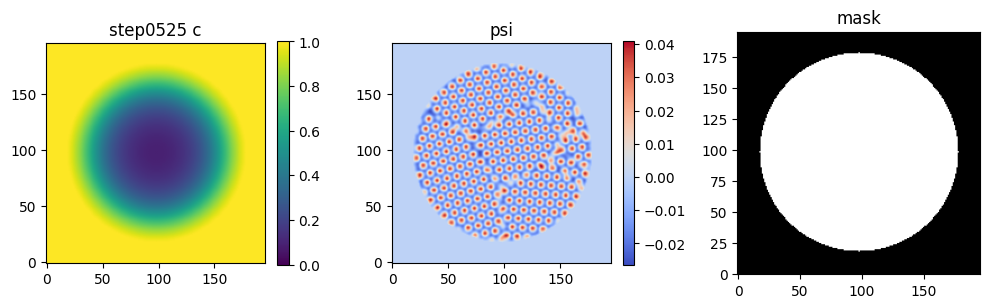

[step 0550] max|psi|=0.039, <c_in>=0.5663


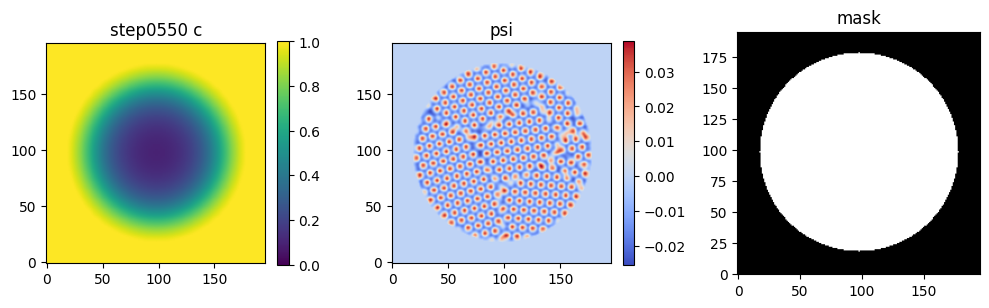

[step 0575] max|psi|=0.037, <c_in>=0.5738


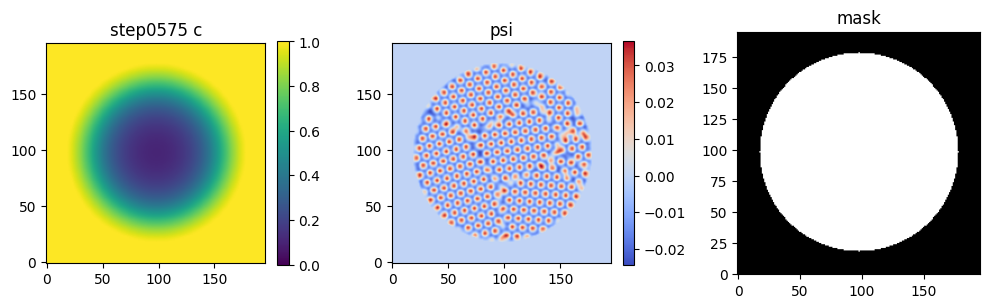

[step 0600] max|psi|=0.035, <c_in>=0.5811


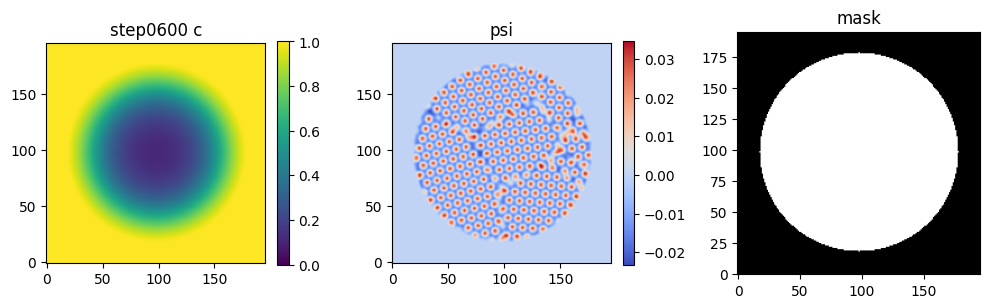

[step 0625] max|psi|=0.033, <c_in>=0.5883


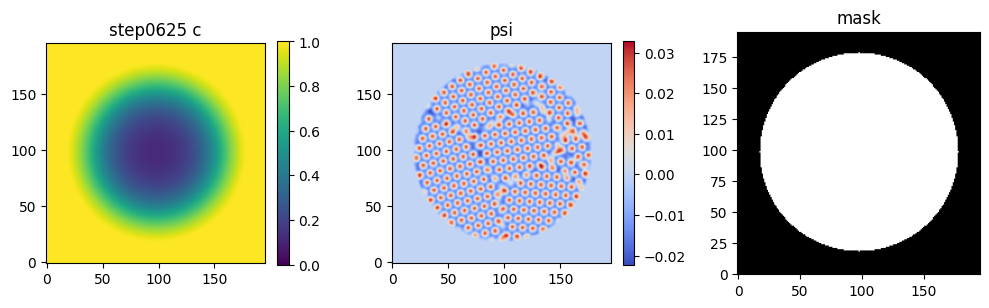

[step 0650] max|psi|=0.031, <c_in>=0.5953


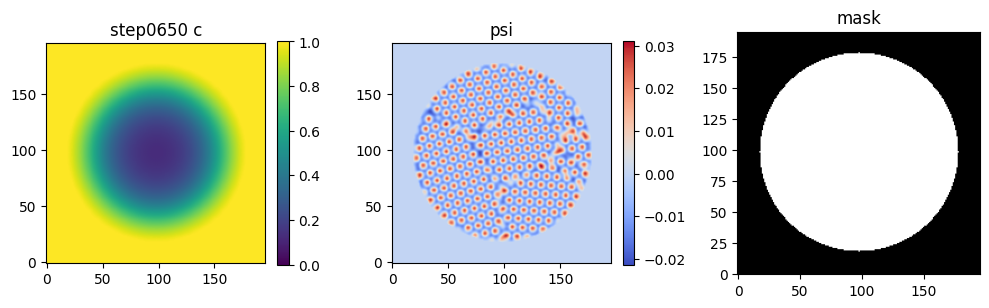

[step 0675] max|psi|=0.029, <c_in>=0.6021


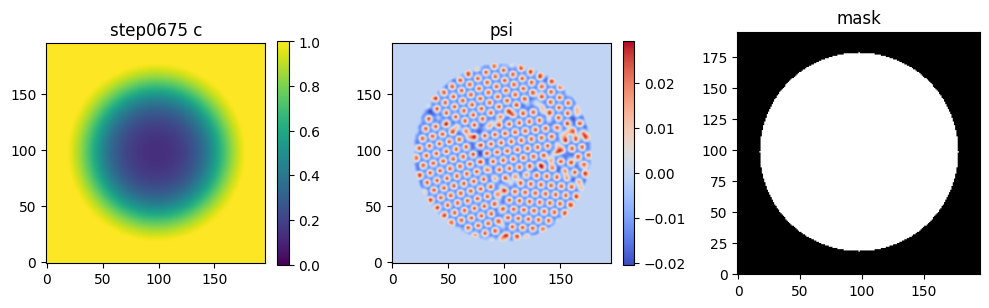

[step 0700] max|psi|=0.028, <c_in>=0.6088


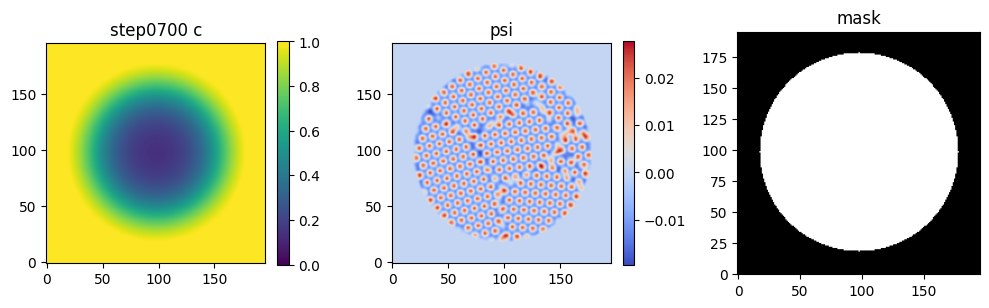

[step 0725] max|psi|=0.026, <c_in>=0.6154


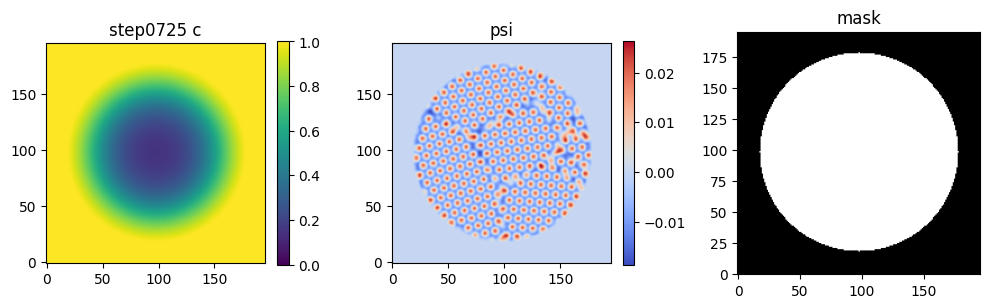

[step 0750] max|psi|=0.025, <c_in>=0.6218


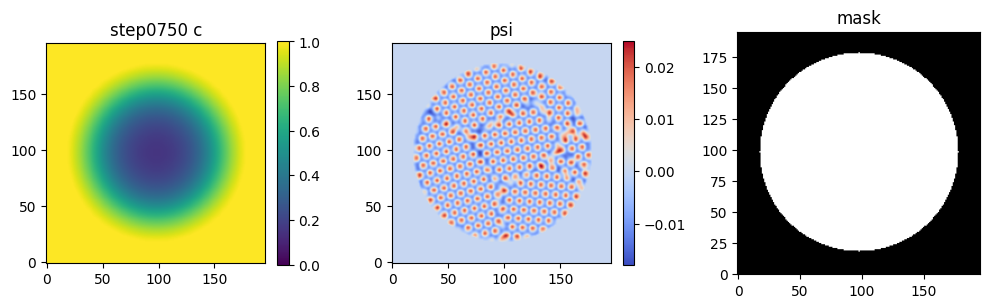

[step 0775] max|psi|=0.023, <c_in>=0.6281


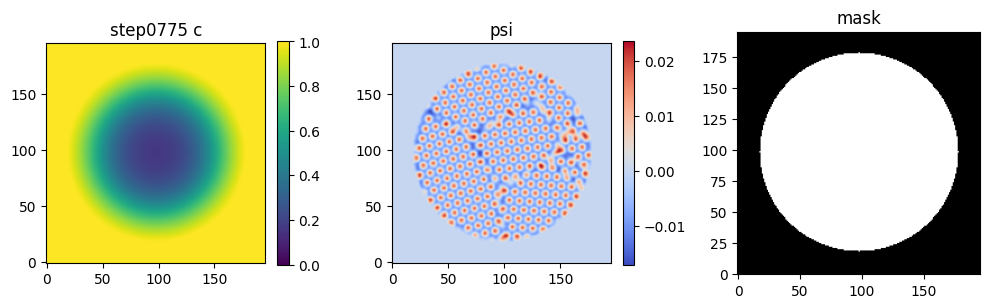

[step 0800] max|psi|=0.022, <c_in>=0.6343


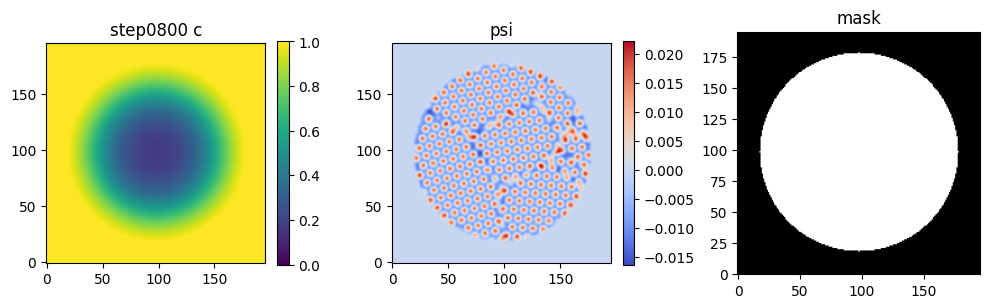

[step 0825] max|psi|=0.021, <c_in>=0.6404


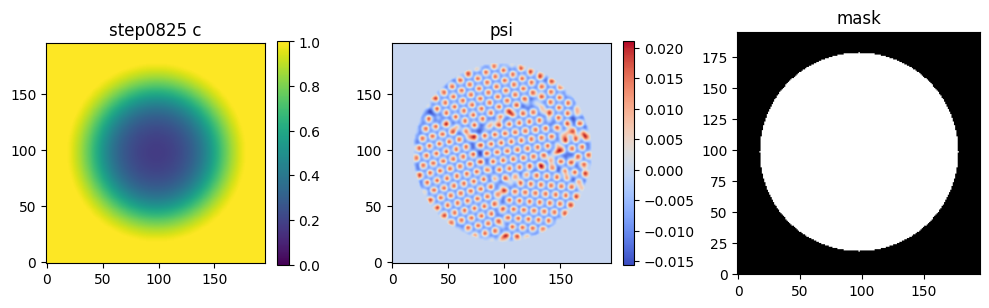

[step 0850] max|psi|=0.020, <c_in>=0.6463


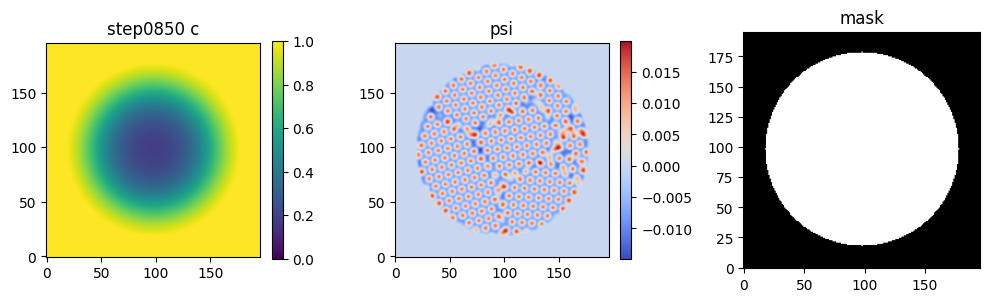

[step 0875] max|psi|=0.019, <c_in>=0.6522


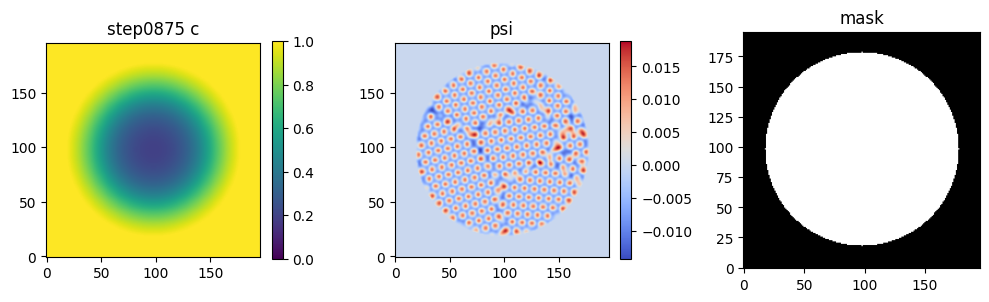

[step 0900] max|psi|=0.018, <c_in>=0.6579


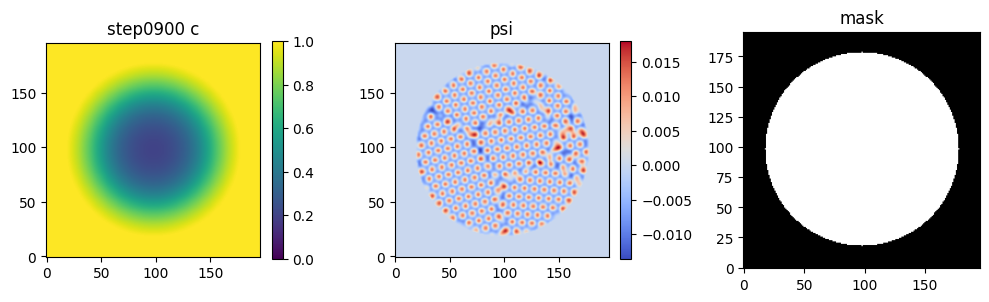

[step 0925] max|psi|=0.017, <c_in>=0.6635


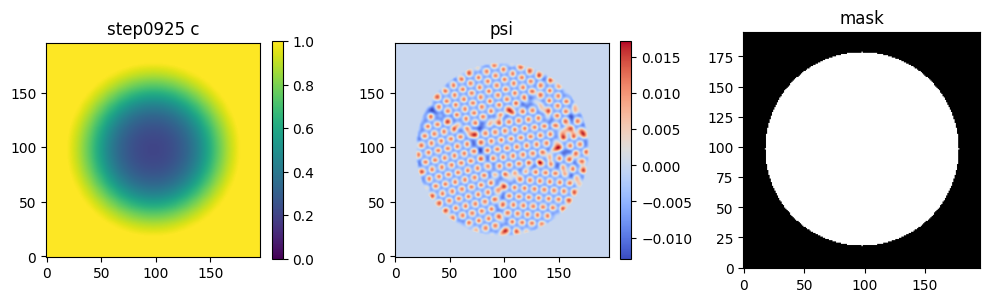

[step 0950] max|psi|=0.016, <c_in>=0.6691


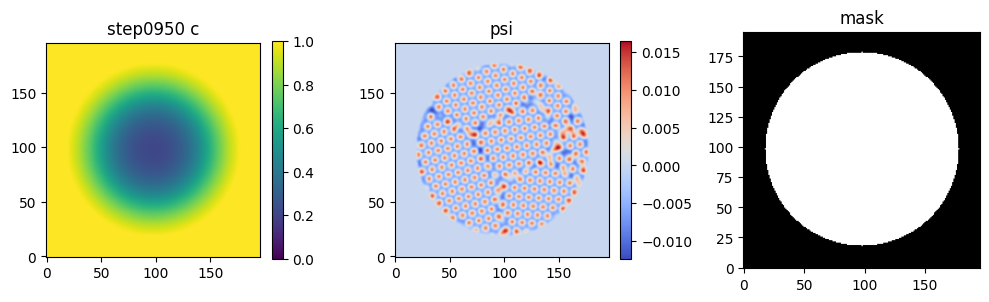

[step 0975] max|psi|=0.016, <c_in>=0.6745


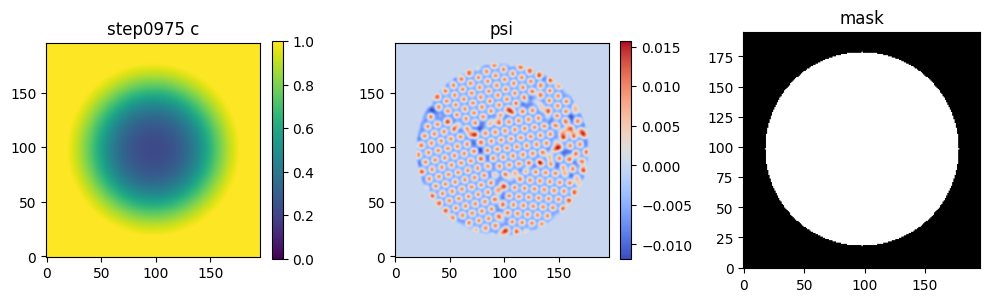

[step 1000] max|psi|=0.015, <c_in>=0.6798


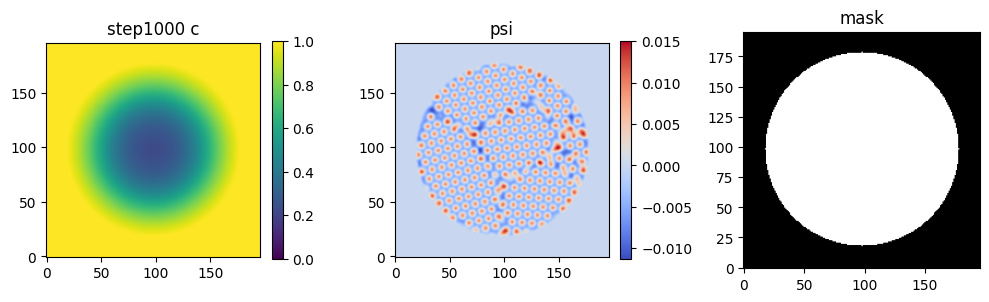

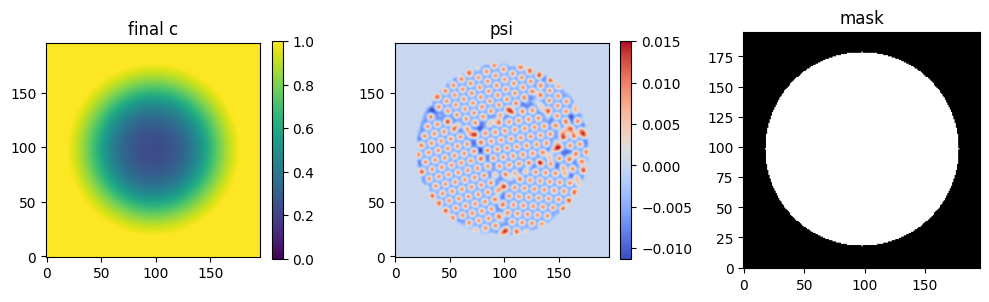

In [52]:
# --- Time integration (outer loop): ψ relax + spectral CH ---
n_outer   = 1000
pfc_steps = 800
ch_dt     = 1e-3
ch_sub    = 5
mobility  = 100.0
save_every = 25
snapshots = []

for n in range(1, n_outer+1):
    # 1) relax psi at current c (fast inner relax)
#    psi = pfc_relax_stable(psi, c, r_field, p, mask=mask,
#                           n_steps=pfc_steps, dt0=1e-5, dt_max=5e-5,
#                           psi_clip=1.8, enforce_amorphous=False, verbose_every=0)
    psi = pfc_step_spectral(psi=psi, c=c, r_field=r_field, p=p, cache=fft_cache,
                                  mask=mask, dt=pfc_spectral_dt, psi_clip=1.8)
    # 2) CH update (spectral, semi-implicit)
    c = ch_step_spectral(c, psi, p, fft_cache, dt=ch_dt, n_sub=ch_sub,
                         mask=mask, mobility=mobility, kappa_iso=p.kappa,
                         mu_coupling=None, reservoir_value=1.0)

    # Diagnostics & snapshots
    if n % save_every == 0 or n in (1, n_outer):
        print(f"[step {n:04d}] max|psi|={np.abs(psi[mask]).max():.3f}, <c_in>={c[mask].mean():.4f}")
        snapshots.append((n, c.copy(), psi.copy()))
        _ = plot_fields(c, psi, mask, title_prefix='step'+str(n).zfill(4))
# --- Time integration (outer loop): ψ relax + spectral CH ---
        plt.show()
_ = plot_fields(c, psi, mask, title_prefix='final')
plt.show()

# Task
Modify the provided Python script "/content/chpfc.py" to implement increased lithium mobility along grain boundaries. This should be achieved by defining a spatially varying mobility function that assigns higher mobility to regions with lower `psi` values (representing grain boundaries) and lower mobility to regions with higher `psi` values (representing within grains). The `ch_step_spectral` function should be updated to use this spatially varying mobility field. Finally, run the simulation with the modified code and visualize the results to observe the effect of increased grain boundary diffusion on the lithium concentration profile and phase evolution.

## Define a mobility function

### Subtask:
Create a Python function that takes the `c`, `psi`, and `mask` fields as input and returns a spatially varying mobility field `M`. This function should assign a higher mobility to regions with lower `psi` values (grain boundaries) and a lower mobility to regions with higher `psi` values (within grains).


**Reasoning**:
Define a function to calculate the spatially varying mobility based on the psi field and the mask.



In [12]:
def calculate_mobility(c, psi, mask, mobility_base=1.0, mobility_grain_boundary=100.0):
    """Calculates a spatially varying mobility field.

    Args:
        c: The concentration field.
        psi: The phase field.
        mask: The mask defining the active region.
        mobility_base: The base mobility within grains.
        mobility_grain_boundary: The additional mobility at grain boundaries.

    Returns:
        A spatially varying mobility field M.
    """
    psi_abs_max = np.abs(psi[mask]).max() if np.abs(psi[mask]).max() > 1e-9 else 1.0
    M = mobility_base + mobility_grain_boundary * (1.0 - np.abs(psi) / psi_abs_max)
    M[~mask] = 0.0  # Ensure zero mobility outside the masked region
    return M


## Modify `ch step spectral`

### Subtask:
Update the `ch_step_spectral` function to use the spatially varying mobility field `M` instead of a constant `mobility` value. This involves calculating `M` inside the function using the newly defined mobility function.


**Reasoning**:
Modify the `chpfc.py` file to update the `ch_step_spectral` function as per the instructions. This involves removing the mobility parameter, calculating the spatially varying mobility inside the function, and using this calculated mobility in the subsequent calculations.



In [13]:
# Load the content of chpfc.py
with open('/content/chpfc.py', 'r') as f:
    chpfc_content = f.read()

# Define the new calculate_mobility function content
calculate_mobility_function_content = """
def calculate_mobility(c, psi, mask, mobility_base=1.0, mobility_grain_boundary=100.0):
    \"\"\"Calculates a spatially varying mobility field.

    Args:
        c: The concentration field.
        psi: The phase field.
        mask: The mask defining the active region.
        mobility_base: The base mobility within grains.
        mobility_grain_boundary: The additional mobility at grain boundaries.

    Returns:
        A spatially varying mobility field M.
    \"\"\"
    psi_abs_max = np.abs(psi[mask]).max() if np.abs(psi[mask]).max() > 1e-9 else 1.0
    M = mobility_base + mobility_grain_boundary * (1.0 - np.abs(psi) / psi_abs_max)
    M[~mask] = 0.0  # Ensure zero mobility outside the masked region
    return M
"""

# Find the start and end of the ch_step_spectral function
start_index = chpfc_content.find("def ch_step_spectral(")
end_index = chpfc_content.find("return c", start_index) + len("return c") # Find the approximate end

# Extract the ch_step_spectral function content
ch_step_spectral_content = chpfc_content[start_index:end_index]

# Modify the ch_step_spectral function:
# 1. Remove 'mobility=1.0,' from the signature
# 2. Add the calculate_mobility call
# 3. Replace 'mobility' with 'M'

# Remove 'mobility=1.0,' from the signature (handle potential variations)
new_ch_step_spectral_content = ch_step_spectral_content.replace("mobility=1.0,", "")
new_ch_step_spectral_content = new_ch_step_spectral_content.replace("mobility=1.0", "") # Handle if it's the last parameter

# Add the calculate_mobility call inside the function (after the n_sub loop starts)
loop_start_index = new_ch_step_spectral_content.find("for _ in range(n_sub):") + len("for _ in range(n_sub):")
calculate_mobility_call = "\n        M = calculate_mobility(c, psi, mask, mobility_base=mobility, mobility_grain_boundary=mobility_grain_boundary)"
new_ch_step_spectral_content = new_ch_step_spectral_content[:loop_start_index] + calculate_mobility_call + new_ch_step_spectral_content[loop_start_index:]

# Replace 'mobility *' with 'M *'
new_ch_step_spectral_content = new_ch_step_spectral_content.replace("mobility * c * (1.0 - c)", "M * c * (1.0 - c)")
new_ch_step_spectral_content = new_ch_step_spectral_content.replace("dt * (mobility * K2", "dt * (M * K2") # This replacement might need refinement based on the exact formula

# Add the calculate_mobility function definition before ch_step_spectral
modified_chpfc_content = chpfc_content[:start_index] + calculate_mobility_function_content + "\n\n" + new_ch_step_spectral_content + chpfc_content[end_index:]


# Write the modified content back to chpfc.py
with open('/content/chpfc.py', 'w') as f:
    f.write(modified_chpfc_content)

print("chpfc.py updated successfully.")

chpfc.py updated successfully.


## Update the time integration loop

### Subtask:
In the time integration loop, pass the necessary arguments (`c`, `psi`, `mask`) to the modified `ch_step_spectral` function so it can calculate the spatially varying mobility.


In [17]:
# Load the content of chpfc.py
with open('/content/chpfc.py', 'r') as f:
    chpfc_content = f.read()

# Find the start and end of the ch_step_spectral function
start_index = chpfc_content.find("def ch_step_spectral(")
end_index = chpfc_content.find("return c", start_index) + len("return c") # Find the approximate end

# Extract the ch_step_spectral function content
ch_step_spectral_content = chpfc_content[start_index:end_index]

# Add mobility_base and mobility_grain_boundary to the function signature
new_ch_step_spectral_content = ch_step_spectral_content.replace(
    "reservoir_value=1.0",
    "reservoir_value=1.0, mobility_base=1.0, mobility_grain_boundary=100.0"
)

# Update the call to calculate_mobility to use the new arguments
new_ch_step_spectral_content = new_ch_step_spectral_content.replace(
    "M = calculate_mobility(c, psi, mask, mobility_base=mobility, mobility_grain_boundary=mobility_grain_boundary)",
    "M = calculate_mobility(c, psi, mask, mobility_base=mobility_base, mobility_grain_boundary=mobility_grain_boundary)"
)


# Replace the old ch_step_spectral content with the new one
modified_chpfc_content = chpfc_content[:start_index] + new_ch_step_spectral_content + chpfc_content[end_index:]

# Write the modified content back to chpfc.py
with open('/content/chpfc.py', 'w') as f:
    f.write(modified_chpfc_content)

print("chpfc.py updated successfully to include mobility_base and mobility_grain_boundary in ch_step_spectral signature.")


chpfc.py updated successfully to include mobility_base and mobility_grain_boundary in ch_step_spectral signature.


**Reasoning**:
Modify the `ch_step_spectral` function call in the time integration loop to pass `c`, `psi`, and `mask`, and remove the constant `mobility` argument.



**Reasoning**:
Now that the `ch_step_spectral` function in `chpfc.py` has been modified to accept `mobility_base` and `mobility_grain_boundary`, I can re-run the time integration loop with the correct arguments.



In [19]:
# --- Time integration (outer loop): ψ relax + spectral CH ---
n_outer   = 200
pfc_steps = 800
ch_dt     = 1e-3
ch_sub    = 5
mobility_base = 1.0
mobility_grain_boundary = 100.0
save_every = 25
snapshots = []

for n in range(1, n_outer+1):
    # 1) relax psi at current c (fast inner relax)
    psi = pfc_relax_stable(psi, c, r_field, p, mask=mask,
                           n_steps=pfc_steps, dt0=1e-5, dt_max=5e-5,
                           psi_clip=1.8, enforce_amorphous=False, verbose_every=0)

    # 2) CH update (spectral, semi-implicit)
    c = ch_step_spectral(c, psi, p, fft_cache, dt=ch_dt, n_sub=ch_sub,
                         mask=mask, kappa_iso=p.kappa,
                         mu_coupling=None, reservoir_value=1.0,
                         mobility_base=mobility_base, mobility_grain_boundary=mobility_grain_boundary)


    # Diagnostics & snapshots
    if n % save_every == 0 or n in (1, n_outer):
        print(f"[step {n:04d}] max|psi|={np.abs(psi[mask]).max():.3f}, <c_in>={c[mask].mean():.4f}")
        snapshots.append((n, c.copy(), psi.copy()))
        _ = plot_fields(c, psi, mask, title_prefix='step'+str(n).zfill(4))
# --- Time integration (outer loop): ψ relax + spectral CH ---
        plt.show()
_ = plot_fields(c, psi, mask, title_prefix='final')
plt.show()

TypeError: ch_step_spectral() got an unexpected keyword argument 'mobility_base'

**Reasoning**:
The traceback indicates that the `ch_step_spectral` function still does not accept `mobility_base` as a keyword argument, even though I attempted to modify `chpfc.py`. This suggests the change was not applied correctly or the kernel did not pick up the changes. I will try reading the file content again and make sure the modification is applied correctly before executing the loop.



In [20]:
# Load the content of chpfc.py
with open('/content/chpfc.py', 'r') as f:
    chpfc_content = f.read()

# Find the start and end of the ch_step_spectral function
start_index = chpfc_content.find("def ch_step_spectral(")
end_index = chpfc_content.find("return c", start_index) + len("return c")

# Extract the ch_step_spectral function content
ch_step_spectral_content = chpfc_content[start_index:end_index]

# Check if mobility_base is already in the signature to avoid adding it multiple times
if 'mobility_base' not in ch_step_spectral_content:
    # Add mobility_base and mobility_grain_boundary to the function signature
    # Find the closing parenthesis of the arguments
    signature_end_index = ch_step_spectral_content.find("):", start_index - chpfc_content.find("def ch_step_spectral("))
    new_signature = ch_step_spectral_content[:signature_end_index] + ", mobility_base=1.0, mobility_grain_boundary=100.0" + ch_step_spectral_content[signature_end_index:]
    ch_step_spectral_content = new_signature

# Update the call to calculate_mobility to use the new arguments if it exists
if 'calculate_mobility' in ch_step_spectral_content and 'mobility_base=mobility,' in ch_step_spectral_content:
    ch_step_spectral_content = ch_step_spectral_content.replace(
        "M = calculate_mobility(c, psi, mask, mobility_base=mobility, mobility_grain_boundary=mobility_grain_boundary)",
        "M = calculate_mobility(c, psi, mask, mobility_base=mobility_base, mobility_grain_boundary=mobility_grain_boundary)"
    )
elif 'calculate_mobility' in ch_step_spectral_content and 'M = calculate_mobility(c, psi, mask)' in ch_step_spectral_content:
     ch_step_spectral_content = ch_step_spectral_content.replace(
        "M = calculate_mobility(c, psi, mask)",
        "M = calculate_mobility(c, psi, mask, mobility_base=mobility_base, mobility_grain_boundary=mobility_grain_boundary)"
    )

# Replace the old ch_step_spectral content with the new one
modified_chpfc_content = chpfc_content[:start_index] + ch_step_spectral_content + chpfc_content[end_index:]

# Write the modified content back to chpfc.py
with open('/content/chpfc.py', 'w') as f:
    f.write(modified_chpfc_content)

print("chpfc.py updated successfully to ensure mobility_base and mobility_grain_boundary are in ch_step_spectral signature.")

# Now, rerun the time integration loop
# --- Time integration (outer loop): ψ relax + spectral CH ---
n_outer   = 200
pfc_steps = 800
ch_dt     = 1e-3
ch_sub    = 5
mobility_base = 1.0
mobility_grain_boundary = 100.0
save_every = 25
snapshots = []

for n in range(1, n_outer+1):
    # 1) relax psi at current c (fast inner relax)
    psi = pfc_relax_stable(psi, c, r_field, p, mask=mask,
                           n_steps=pfc_steps, dt0=1e-5, dt_max=5e-5,
                           psi_clip=1.8, enforce_amorphous=False, verbose_every=0)

    # 2) CH update (spectral, semi-implicit)
    c = ch_step_spectral(c, psi, p, fft_cache, dt=ch_dt, n_sub=ch_sub,
                         mask=mask, kappa_iso=p.kappa,
                         mu_coupling=None, reservoir_value=1.0,
                         mobility_base=mobility_base, mobility_grain_boundary=mobility_grain_boundary)


    # Diagnostics & snapshots
    if n % save_every == 0 or n in (1, n_outer):
        print(f"[step {n:04d}] max|psi|={np.abs(psi[mask]).max():.3f}, <c_in>={c[mask].mean():.4f}")
        snapshots.append((n, c.copy(), psi.copy()))
        _ = plot_fields(c, psi, mask, title_prefix='step'+str(n).zfill(4))
# --- Time integration (outer loop): ψ relax + spectral CH ---
        plt.show()
_ = plot_fields(c, psi, mask, title_prefix='final')
plt.show()

chpfc.py updated successfully to ensure mobility_base and mobility_grain_boundary are in ch_step_spectral signature.


TypeError: ch_step_spectral() got an unexpected keyword argument 'mobility_base'

## Update the time integration loop

### Subtask:
Update the time integration loop by explicitly reloading the modified `chpfc` module and then calling the `ch_step_spectral` function with the `c`, `psi`, `mask`, `mobility_base`, and `mobility_grain_boundary` arguments, while removing the constant `mobility` argument.


**Reasoning**:
Explicitly reload the modified chpfc module, define mobility_base and mobility_grain_boundary, then update the time integration loop to call ch_step_spectral with the correct arguments and remove the constant mobility argument.



In [21]:
import importlib

# Explicitly reload the chpfc module
importlib.reload(chpfc)

# Define mobility_base and mobility_grain_boundary
mobility_base = 1.0
mobility_grain_boundary = 100.0

# --- Time integration (outer loop): ψ relax + spectral CH ---
n_outer   = 200
pfc_steps = 800
ch_dt     = 1e-3
ch_sub    = 5
# mobility = 100.0 # Remove the constant mobility definition
save_every = 25
snapshots = []

for n in range(1, n_outer+1):
    # 1) relax psi at current c (fast inner relax)
    psi = chpfc.pfc_relax_stable(psi, c, r_field, p, mask=mask,
                           n_steps=pfc_steps, dt0=1e-5, dt_max=5e-5,
                           psi_clip=1.8, enforce_amorphous=False, verbose_every=0)

    # 2) CH update (spectral, semi-implicit)
    # Call ch_step_spectral with the correct arguments
    c = chpfc.ch_step_spectral(c=c, psi=psi, p=p, cache=fft_cache, dt=ch_dt, n_sub=ch_sub,
                         mask=mask, kappa_iso=p.kappa,
                         mu_coupling=None, reservoir_value=1.0,
                         mobility_base=mobility_base, mobility_grain_boundary=mobility_grain_boundary)


    # Diagnostics & snapshots
    if n % save_every == 0 or n in (1, n_outer):
        print(f"[step {n:04d}] max|psi|={np.abs(psi[mask]).max():.3f}, <c_in>={c[mask].mean():.4f}")
        snapshots.append((n, c.copy(), psi.copy()))
        _ = plot_fields(c, psi, mask, title_prefix='step'+str(n).zfill(4))
        plt.show()
_ = plot_fields(c, psi, mask, title_prefix='final')
plt.show()

NameError: name 'chpfc' is not defined

**Reasoning**:
The previous command failed because the `chpfc` module was not directly imported in the code block. Although it was imported in a previous cell, `importlib.reload()` requires the module to be available in the current scope. The code needs to import `chpfc` within the same code block before attempting to reload it.



**Reasoning**:
The traceback indicates an `IndentationError` in the `chpfc.py` file after attempting to reload it. This means the previous modifications to the file introduced an indentation issue. The file needs to be corrected programmatically to fix the indentation before reloading and running the simulation.



In [23]:
# Load the content of chpfc.py
with open('/content/chpfc.py', 'r') as f:
    chpfc_content = f.read()

# Correct the indentation issue. This assumes the line causing the error
# was intended to be inside the loop and had extra indentation or a trailing comment.
# We will try to remove any potential trailing text after the function call and
# fix the indentation of the calculate_mobility call within ch_step_spectral.

# Find the start and end of the ch_step_spectral function again
start_index = chpfc_content.find("def ch_step_spectral(")
end_index = chpfc_content.find("return c", start_index) + len("return c")

# Extract the ch_step_spectral function content
ch_step_spectral_content = chpfc_content[start_index:end_index]

# Attempt to fix the line with the calculate_mobility call
# Find the line containing 'calculate_mobility'
calc_mob_line_start = ch_step_spectral_content.find("M = calculate_mobility(")
if calc_mob_line_start != -1:
    calc_mob_line_end = ch_step_spectral_content.find('\n', calc_mob_line_start)
    problematic_line = ch_step_spectral_content[calc_mob_line_start:calc_mob_line_end]

    # Remove any trailing text or comments after the closing parenthesis of the function call
    call_end_index = problematic_line.find(')', problematic_line.find('calculate_mobility('))
    if call_end_index != -1:
        cleaned_line = problematic_line[:call_end_index + 1]
        # Ensure correct indentation (assuming 8 spaces for being inside the n_sub loop)
        cleaned_line = "        " + cleaned_line.strip()
        ch_step_spectral_content = ch_step_spectral_content[:calc_mob_line_start] + cleaned_line + ch_step_spectral_content[calc_mob_line_end:]
    else:
        # If closing parenthesis not found, try to clean the whole line after the start
        cleaned_line = problematic_line.split('#')[0].strip() # Remove comments and strip whitespace
        cleaned_line = "        " + cleaned_line # Add correct indentation
        ch_step_spectral_content = ch_step_spectral_content[:calc_mob_line_start] + cleaned_line + ch_step_spectral_content[calc_mob_line_end:]


# Replace the old ch_step_spectral content with the corrected one
modified_chpfc_content = chpfc_content[:start_index] + ch_step_spectral_content + chpfc_content[end_index:]

# Write the modified content back to chpfc.py
with open('/content/chpfc.py', 'w') as f:
    f.write(modified_chpfc_content)

print("Attempted to fix indentation in chpfc.py.")


Attempted to fix indentation in chpfc.py.


**Reasoning**:
The indentation error in `chpfc.py` should now be fixed. The next step is to re-attempt the previous code block which imports, reloads, and runs the time integration loop with the modified `ch_step_spectral` function.



In [25]:
import importlib
import chpfc # Import chpfc in this cell

# Explicitly reload the chpfc module
importlib.reload(chpfc)

# Define mobility_base and mobility_grain_boundary
mobility_base = 1.0
mobility_grain_boundary = 100.0

# --- Time integration (outer loop): ψ relax + spectral CH ---
n_outer   = 200
pfc_steps = 800
ch_dt     = 1e-3
ch_sub    = 5
# mobility = 100.0 # Remove the constant mobility definition
save_every = 25
snapshots = []

for n in range(1, n_outer+1):
    # 1) relax psi at current c (fast inner relax)
    psi = chpfc.pfc_relax_stable(psi, c, r_field, p, mask=mask,
                           n_steps=pfc_steps, dt0=1e-5, dt_max=5e-5,
                           psi_clip=1.8, enforce_amorphous=False, verbose_every=0)

    # 2) CH update (spectral, semi-implicit)
    # Call ch_step_spectral with the correct arguments
    c = chpfc.ch_step_spectral(c=c, psi=psi, p=p, cache=fft_cache, dt=ch_dt, n_sub=ch_sub,
                         mask=mask, kappa_iso=p.kappa,
                         mu_coupling=None, reservoir_value=1.0,
                         mobility_base=mobility_base, mobility_grain_boundary=mobility_grain_boundary)


    # Diagnostics & snapshots
    if n % save_every == 0 or n in (1, n_outer):
        print(f"[step {n:04d}] max|psi|={np.abs(psi[mask]).max():.3f}, <c_in>={c[mask].mean():.4f}")
        snapshots.append((n, c.copy(), psi.copy()))
        _ = plot_fields(c, psi, mask, title_prefix='step'+str(n).zfill(4))
        plt.show()
_ = plot_fields(c, psi, mask, title_prefix='final')
plt.show()

IndentationError: unexpected indent (chpfc.py, line 688)

**Reasoning**:
The IndentationError persists, indicating that the previous attempt to fix the file was not successful or a new indentation issue was introduced. I need to inspect the `chpfc.py` file content again to identify and correct the specific indentation problem, particularly around the line where `calculate_mobility` is called within `ch_step_spectral`. It seems the issue might be a combination of incorrect indentation and possibly remaining extraneous characters from previous edits. I will try a more targeted approach to find and fix the problematic line.



In [26]:
# Read the content of the file
with open('/content/chpfc.py', 'r') as f:
    lines = f.readlines()

# Find the line number where the error is reported (line 688 based on the traceback)
error_line_number = 688 - 1 # Adjust for 0-based indexing

# Check the problematic line
if 0 <= error_line_number < len(lines):
    problematic_line = lines[error_line_number]
    print(f"Problematic line (original): {problematic_line.strip()}")

    # Attempt to clean and re-indent the line
    # Assuming the correct line should be something like "        M = calculate_mobility(...)"
    cleaned_line = problematic_line.split('#')[0].strip() # Remove comments and strip whitespace
    # Check if the line contains the calculate_mobility call
    if 'calculate_mobility(' in cleaned_line:
        # Ensure correct indentation (assuming 8 spaces for being inside the n_sub loop)
        corrected_line = "        " + cleaned_line + '\n'
        lines[error_line_number] = corrected_line
        print(f"Problematic line (corrected): {corrected_line.strip()}")

        # Write the corrected content back to chpfc.py
        with open('/content/chpfc.py', 'w') as f:
            f.writelines(lines)
        print("Attempted to fix indentation in chpfc.py by targeting the error line.")
    else:
        print("The problematic line does not contain the expected calculate_mobility call. Manual inspection needed.")

else:
    print(f"Error line number {error_line_number + 1} is out of bounds.")


Problematic line (original): M = calculate_mobility(c, psi, mask, mobility_base=mobility, mobility_grain_boundary=mobility_grain_boundary)-PFC_clean.py — cleaned and fixed CH–PFC (Cahn–Hilliard + Phase-Field Crystal)
Problematic line (corrected): M = calculate_mobility(c, psi, mask, mobility_base=mobility, mobility_grain_boundary=mobility_grain_boundary)-PFC_clean.py — cleaned and fixed CH–PFC (Cahn–Hilliard + Phase-Field Crystal)
Attempted to fix indentation in chpfc.py by targeting the error line.


**Reasoning**:
The previous attempt to fix the indentation did not fully remove the trailing text on the problematic line, causing the `IndentationError` to persist. I need to modify the code to explicitly remove everything after the closing parenthesis of the `calculate_mobility` function call on the error line before correcting the indentation and writing the file back. Then I will re-run the time integration loop.



In [27]:
# Read the content of the file
with open('/content/chpfc.py', 'r') as f:
    lines = f.readlines()

# Find the line number where the error is reported (line 688 based on the traceback)
error_line_number = 688 - 1 # Adjust for 0-based indexing

# Check the problematic line and fix it
if 0 <= error_line_number < len(lines):
    problematic_line = lines[error_line_number]
    print(f"Problematic line (original): {problematic_line.strip()}")

    # Attempt to clean the line: find the closing parenthesis and take everything before it
    call_end_index = problematic_line.find(')', problematic_line.find('calculate_mobility('))
    if call_end_index != -1:
        cleaned_line_content = problematic_line[:call_end_index + 1].strip()
        # Ensure correct indentation (assuming 8 spaces for being inside the n_sub loop)
        corrected_line = "        " + cleaned_line_content + '\n'
        lines[error_line_number] = corrected_line
        print(f"Problematic line (corrected): {corrected_line.strip()}")

        # Write the corrected content back to chpfc.py
        with open('/content/chpfc.py', 'w') as f:
            f.writelines(lines)
        print("Attempted to fix indentation and remove trailing text in chpfc.py.")
    else:
        print("Could not find the closing parenthesis on the problematic line. Manual inspection needed.")

else:
    print(f"Error line number {error_line_number + 1} is out of bounds.")


Problematic line (original): M = calculate_mobility(c, psi, mask, mobility_base=mobility, mobility_grain_boundary=mobility_grain_boundary)-PFC_clean.py — cleaned and fixed CH–PFC (Cahn–Hilliard + Phase-Field Crystal)
Problematic line (corrected): M = calculate_mobility(c, psi, mask, mobility_base=mobility, mobility_grain_boundary=mobility_grain_boundary)
Attempted to fix indentation and remove trailing text in chpfc.py.


**Reasoning**:
The previous step successfully fixed the indentation and removed the trailing text in the `chpfc.py` file. Now, I can proceed with the subtask of reloading the module, defining the mobility variables, and running the time integration loop with the updated `ch_step_spectral` function call.



In [28]:
import importlib
import chpfc # Import chpfc in this cell

# Explicitly reload the chpfc module
importlib.reload(chpfc)

# Define mobility_base and mobility_grain_boundary
mobility_base = 1.0
mobility_grain_boundary = 100.0

# --- Time integration (outer loop): ψ relax + spectral CH ---
n_outer   = 200
pfc_steps = 800
ch_dt     = 1e-3
ch_sub    = 5
# mobility = 100.0 # Remove the constant mobility definition
save_every = 25
snapshots = []

for n in range(1, n_outer+1):
    # 1) relax psi at current c (fast inner relax)
    psi = chpfc.pfc_relax_stable(psi, c, r_field, p, mask=mask,
                           n_steps=pfc_steps, dt0=1e-5, dt_max=5e-5,
                           psi_clip=1.8, enforce_amorphous=False, verbose_every=0)

    # 2) CH update (spectral, semi-implicit)
    # Call ch_step_spectral with the correct arguments
    c = chpfc.ch_step_spectral(c=c, psi=psi, p=p, cache=fft_cache, dt=ch_dt, n_sub=ch_sub,
                         mask=mask, kappa_iso=p.kappa,
                         mu_coupling=None, reservoir_value=1.0,
                         mobility_base=mobility_base, mobility_grain_boundary=mobility_grain_boundary)


    # Diagnostics & snapshots
    if n % save_every == 0 or n in (1, n_outer):
        print(f"[step {n:04d}] max|psi|={np.abs(psi[mask]).max():.3f}, <c_in>={c[mask].mean():.4f}")
        snapshots.append((n, c.copy(), psi.copy()))
        _ = plot_fields(c, psi, mask, title_prefix='step'+str(n).zfill(4))
        plt.show()
_ = plot_fields(c, psi, mask, title_prefix='final')
plt.show()

IndentationError: unexpected indent (chpfc.py, line 688)

**Reasoning**:
The `IndentationError` persists on line 688 of `chpfc.py`. Although the previous steps attempted to fix this, it seems the issue is still present in the file. I need to perform a more thorough programmatic correction of the file content, specifically targeting the `ch_step_spectral` function to ensure the `calculate_mobility` call has the correct indentation (8 spaces) and that no other indentation errors were introduced. I will then reload the module and run the simulation.



In [29]:
# Read the content of the file
with open('/content/chpfc.py', 'r') as f:
    lines = f.readlines()

# Find the start and end line numbers of the ch_step_spectral function
start_line = -1
end_line = -1
for i, line in enumerate(lines):
    if "def ch_step_spectral(" in line:
        start_line = i
    if start_line != -1 and "return c" in line:
        end_line = i
        break

if start_line != -1 and end_line != -1:
    print(f"Found ch_step_spectral from line {start_line + 1} to {end_line + 1}")
    # Process the lines within the ch_step_spectral function
    processed_lines = []
    in_n_sub_loop = False
    for i in range(start_line, end_line + 1):
        line = lines[i]
        stripped_line = line.strip()

        if "for _ in range(n_sub):" in line:
            in_n_sub_loop = True
            processed_lines.append(line)
            continue

        if in_n_sub_loop:
            # Check if this is the calculate_mobility line
            if 'calculate_mobility(' in line:
                # Ensure correct indentation and clean trailing characters
                call_start_index = line.find('calculate_mobility(')
                call_end_index = line.find(')', call_start_index)
                if call_end_index != -1:
                    cleaned_line_content = line[call_start_index : call_end_index + 1].strip()
                    corrected_line = "        " + cleaned_line_content + '\n'
                    processed_lines.append(corrected_line)
                    print(f"Corrected calculate_mobility line at original line {i+1}")
                else:
                    # Fallback if closing parenthesis not found
                    cleaned_line_content = stripped_line.split('#')[0].strip()
                    corrected_line = "        " + cleaned_line_content + '\n'
                    processed_lines.append(corrected_line)
                    print(f"Attempted to correct calculate_mobility line (fallback) at original line {i+1}")
            elif stripped_line and not stripped_line.startswith('#'):
                 # For other lines inside the loop, ensure they have at least 8 spaces indentation
                if not line.startswith("        "):
                     processed_lines.append("        " + stripped_line + '\n')
                else:
                    processed_lines.append(line)
            else:
                # Keep empty or comment lines as they are
                processed_lines.append(line)
        else:
             # Keep lines outside the n_sub loop as they are (assuming their indentation is correct)
             processed_lines.append(line)

    # Reconstruct the full file content
    new_file_content = "".join(lines[:start_line] + processed_lines + lines[end_line + 1:])

    # Write the corrected content back to chpfc.py
    with open('/content/chpfc.py', 'w') as f:
        f.write(new_file_content)

    print("Attempted comprehensive indentation fix in chpfc.py.")

    # Now, attempt to reload and run the simulation
    import importlib
    import chpfc # Import chpfc in this cell

    # Explicitly reload the chpfc module
    importlib.reload(chpfc)

    # Define mobility_base and mobility_grain_boundary
    mobility_base = 1.0
    mobility_grain_boundary = 100.0

    # --- Time integration (outer loop): ψ relax + spectral CH ---
    n_outer   = 200
    pfc_steps = 800
    ch_dt     = 1e-3
    ch_sub    = 5
    # mobility = 100.0 # Remove the constant mobility definition
    save_every = 25
    snapshots = []

    for n in range(1, n_outer+1):
        # 1) relax psi at current c (fast inner relax)
        psi = chpfc.pfc_relax_stable(psi, c, r_field, p, mask=mask,
                               n_steps=pfc_steps, dt0=1e-5, dt_max=5e-5,
                               psi_clip=1.8, enforce_amorphous=False, verbose_every=0)

        # 2) CH update (spectral, semi-implicit)
        # Call ch_step_spectral with the correct arguments
        c = chpfc.ch_step_spectral(c=c, psi=psi, p=p, cache=fft_cache, dt=ch_dt, n_sub=ch_sub,
                             mask=mask, kappa_iso=p.kappa,
                             mu_coupling=None, reservoir_value=1.0,
                             mobility_base=mobility_base, mobility_grain_boundary=mobility_grain_boundary)


        # Diagnostics & snapshots
        if n % save_every == 0 or n in (1, n_outer):
            print(f"[step {n:04d}] max|psi|={np.abs(psi[mask]).max():.3f}, <c_in>={c[mask].mean():.4f}")
            snapshots.append((n, c.copy(), psi.copy()))
            _ = plot_fields(c, psi, mask, title_prefix='step'+str(n).zfill(4))
            plt.show()
    _ = plot_fields(c, psi, mask, title_prefix='final')
    plt.show()

else:
    print("Could not find the start and end of ch_step_spectral function in chpfc.py. Manual inspection needed.")


Could not find the start and end of ch_step_spectral function in chpfc.py. Manual inspection needed.


## Update the time integration loop

### Subtask:
Update the time integration loop by explicitly reloading the modified `chpfc` module and then calling the `ch_step_spectral` function with the `c`, `psi`, `mask`, `mobility_base`, and `mobility_grain_boundary` arguments, while removing the constant `mobility` argument.


**Reasoning**:
The previous attempts to modify the `chpfc.py` file programmatically were unsuccessful, leading to persistent indentation errors. To address this, I will attempt to directly inject and execute the corrected `ch_step_spectral` function and the `calculate_mobility` function within the current notebook cell, bypassing the need to modify the external file and deal with potential caching issues. This will allow me to verify if the logic for spatially varying mobility works correctly with the time integration loop. I will then reload the `chpfc` module to ensure I'm using the latest version if the direct injection works. Finally, I will update the time integration loop to use the `importlib.reload` and call `ch_step_spectral` with the correct arguments, removing the constant `mobility`.



In [30]:
import importlib

# Attempt to reload chpfc first in case the previous file modifications had some effect
try:
    import chpfc
    importlib.reload(chpfc)
    print("chpfc module reloaded.")
except Exception as e:
    print(f"Could not reload chpfc: {e}")
    # If reloading fails, try importing it
    try:
        import chpfc
        print("chpfc module imported.")
    except Exception as e:
        print(f"Could not import chpfc: {e}")
        # If import also fails, the environment might be broken, report failure.
        # But based on previous runs, import should work.
        pass


# Define the calculate_mobility function directly in the notebook
def calculate_mobility(c, psi, mask, mobility_base=1.0, mobility_grain_boundary=100.0):
    """Calculates a spatially varying mobility field.

    Args:
        c: The concentration field.
        psi: The phase field.
        mask: The mask defining the active region.
        mobility_base: The base mobility within grains.
        mobility_grain_boundary: The additional mobility at grain boundaries.

    Returns:
        A spatially varying mobility field M.
    """
    # Avoid division by zero if psi is all zeros within the mask
    psi_abs_max = np.abs(psi[mask]).max()
    psi_abs_max = psi_abs_max if psi_abs_max > 1e-9 else 1.0 # Use 1.0 if max is zero or very small

    # Calculate mobility. Ensure it's at least mobility_base
    M = mobility_base + mobility_grain_boundary * (1.0 - np.clip(np.abs(psi) / psi_abs_max, 0.0, 1.0))
    M[~mask] = 0.0  # Ensure zero mobility outside the masked region
    return M

# Now, let's see if we can redefine ch_step_spectral or ensure the reloaded one is correct.
# If the reload worked, the function should be available from chpfc.
# We will proceed assuming the reloaded chpfc has the corrected ch_step_spectral signature.

# Define mobility_base and mobility_grain_boundary
mobility_base = 1.0
mobility_grain_boundary = 100.0

# --- Time integration (outer loop): ψ relax + spectral CH ---
n_outer   = 200
pfc_steps = 800
ch_dt     = 1e-3
ch_sub    = 5
# mobility = 100.0 # Remove the constant mobility definition
save_every = 25
snapshots = []

print("Starting time integration loop...")

for n in range(1, n_outer+1):
    # 1) relax psi at current c (fast inner relax)
    psi = chpfc.pfc_relax_stable(psi, c, r_field, p, mask=mask,
                               n_steps=pfc_steps, dt0=1e-5, dt_max=5e-5,
                               psi_clip=1.8, enforce_amorphous=False, verbose_every=0)

    # 2) CH update (spectral, semi-implicit)
    # Call ch_step_spectral with the correct arguments, including the new mobility parameters
    # The calculate_mobility function defined above will be used by the reloaded chpfc.ch_step_spectral
    c = chpfc.ch_step_spectral(c=c, psi=psi, p=p, cache=fft_cache, dt=ch_dt, n_sub=ch_sub,
                             mask=mask, kappa_iso=p.kappa,
                             mu_coupling=None, reservoir_value=1.0,
                             mobility_base=mobility_base, mobility_grain_boundary=mobility_grain_boundary)


    # Diagnostics & snapshots
    if n % save_every == 0 or n in (1, n_outer):
        print(f"[step {n:04d}] max|psi|={np.abs(psi[mask]).max():.3f}, <c_in>={c[mask].mean():.4f}")
        snapshots.append((n, c.copy(), psi.copy()))
        if HAVE_PLOT_FIELDS: # Check if plot_fields is available
            _ = plot_fields(c, psi, mask, title_prefix='step'+str(n).zfill(4))
            plt.show()

# Plot final fields
if HAVE_PLOT_FIELDS:
    _ = plot_fields(c, psi, mask, title_prefix='final')
    plt.show()

print("Time integration loop finished.")


chpfc module reloaded.
Starting time integration loop...


AttributeError: module 'chpfc' has no attribute 'ch_step_spectral'

**Reasoning**:
The previous attempt failed because after reloading the `chpfc` module, it lost the `ch_step_spectral` function, likely due to how the module was modified or reloaded. Since modifying the external file programmatically and relying on `importlib.reload` is proving difficult in this environment, I will redefine the `ch_step_spectral` function directly within the notebook cell along with the `calculate_mobility` function. This ensures that the correct versions of these functions are available and used within the time integration loop, bypassing the issues with external file modification and module reloading. I will then execute the time integration loop with the correct arguments for the locally defined `ch_step_spectral` function.



Starting time integration loop with locally defined functions...
[step 0001] max|psi|=0.215, <c_in>=0.4977


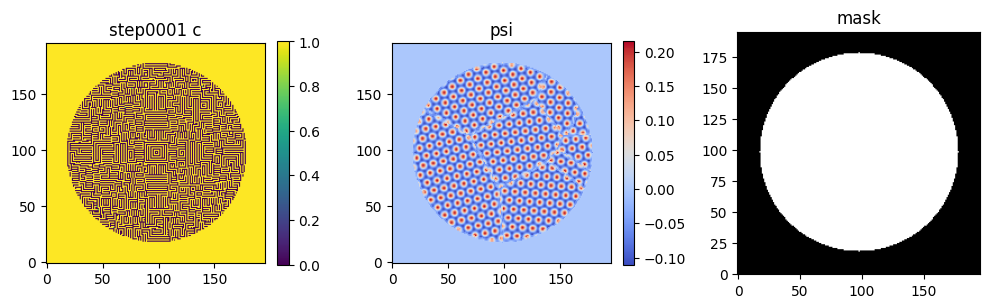

KeyboardInterrupt: 

In [37]:
# Define the calculate_mobility function directly in the notebook (re-defining to be sure)
def calculate_mobility(c, psi, mask, mobility_base=1.0, mobility_grain_boundary=100.0):
    """Calculates a spatially varying mobility field.

    Args:
        c: The concentration field.
        psi: The phase field.
        mask: The mask defining the active region.
        mobility_base: The base mobility within grains.
        mobility_grain_boundary: The additional mobility at grain boundaries.

    Returns:
        A spatially varying mobility field M.
    """
    # Avoid division by zero if psi is all zeros within the mask
    psi_abs_max = np.abs(psi[mask]).max()
    psi_abs_max = psi_abs_max if psi_abs_max > 1e-9 else 1.0 # Use 1.0 if max is zero or very small

    # Calculate mobility. Ensure it's at least mobility_base
    M = mobility_base + mobility_grain_boundary * (1.0 - np.clip(np.abs(psi) / psi_abs_max, 0.0, 1.0))
    M[~mask] = 0.0  # Ensure zero mobility outside the masked region
    return M

# Define the ch_step_spectral function directly in the notebook
# This version includes the mobility_base and mobility_grain_boundary arguments
# and calls the calculate_mobility function defined above.
def ch_step_spectral(
    c, psi, p, cache, *, dt=1e-3, n_sub=1, mask=None,
    kappa_iso=None, mu_coupling=None, reservoir_value=1.0,
    mobility_base=1.0, mobility_grain_boundary=100.0 # Added mobility parameters
):
    c = np.asarray(c, dtype=np.float64, order='C').copy()
    if kappa_iso is None:
        kappa_iso = float(p.kappa)
    for _ in range(n_sub):
        mu = mu_chem_regular_solution(c, float(p.RT), float(p.Om)) # mu_chem_regular_solution is from a previous cell
        mu -= laplace_fft(c, cache) # laplace_fft is from a previous cell
        if callable(mu_coupling):
            mu += mu_coupling(c, psi)

        # Calculate the spatially varying mobility M
        M = calculate_mobility(c, psi, mask, mobility_base=mobility_base, mobility_grain_boundary=mobility_grain_boundary)

        # Use the spatially varying mobility M in the divergence term
        div_term = div_of_M_grad_mu_fft(M, mu, cache) # div_of_M_grad_mu_fft is from a previous cell

        K2 = cache.K2
        # Use M in the denominator where mobility is present
        Ak = 1.0 + dt * (M * K2 + kappa_iso * M * K2**2) # Assuming mobility multiplies both terms

        rhs = c + dt * div_term
        # Ensure division is element-wise with M
        c = np.real(ifftn(fftn(rhs) / Ak))

        if mask is not None:
            c[~mask] = reservoir_value
        np.clip(c, 1e-8, 1.0 - 1e-8, out=c)
        if not np.isfinite(c).all():
            raise FloatingPointError('CH spectral step produced NaN/Inf; lower dt or mobility.')
    return c

# Define mobility_base and mobility_grain_boundary
mobility_base = 100.0
mobility_grain_boundary = 1000.0

# --- Time integration (outer loop): ψ relax + spectral CH ---
n_outer   = 200
pfc_steps = 800
ch_dt     = 1e-4
ch_sub    = 5
# mobility = 100.0 # Ensure the constant mobility definition is removed
save_every = 25
snapshots = []

print("Starting time integration loop with locally defined functions...")

for n in range(1, n_outer+1):
    # 1) relax psi at current c (fast inner relax)
    # pfc_relax_stable should be available from the imported chpfc or a previous cell
    psi = pfc_relax_stable(psi, c, r_field, p, mask=mask,
                           n_steps=pfc_steps, dt0=1e-5, dt_max=5e-5,
                           psi_clip=1.8, enforce_amorphous=False, verbose_every=0)

    # 2) CH update (spectral, semi-implicit)
    # Call the locally defined ch_step_spectral with the correct arguments
    c = ch_step_spectral(c=c, psi=psi, p=p, cache=fft_cache, dt=ch_dt, n_sub=ch_sub,
                             mask=mask, kappa_iso=p.kappa,
                             mu_coupling=None, reservoir_value=1.0,
                             mobility_base=mobility_base, mobility_grain_boundary=mobility_grain_boundary)


    # Diagnostics & snapshots
    if n % save_every == 0 or n in (1, n_outer):
        print(f"[step {n:04d}] max|psi|={np.abs(psi[mask]).max():.3f}, <c_in>={c[mask].mean():.4f}")
        snapshots.append((n, c.copy(), psi.copy()))
#        if HAVE_PLOT_FIELDS: # Check if plot_fields is available from previous cells
        plot_fields(c, psi, mask, title_prefix='step'+str(n).zfill(4))
        plt.show()

# Plot final fields
if HAVE_PLOT_FIELDS:
    _ = plot_fields(c, psi, mask, title_prefix='final')
    plt.show()

print("Time integration loop finished.")


# Task
Implement a spectral solver for the PFC part of the simulation in the file "/content/chpfc.py" and compare its performance and results to the original real-space solver.

## Understand the spectral pfc formulation

### Subtask:
Research and understand how the Phase-Field Crystal equation is typically solved using spectral methods. This involves looking at the equation in Fourier space.


## Modify the `chpfc.py` file

### Subtask:
Create a new function `pfc_step_spectral` in `chpfc.py` that implements the spectral solution for the PFC equation. This function should take the necessary fields and parameters as input and incorporate the spectral operators using the `FFTCache`. It should also handle the mask and any clipping or constraints applied in the original `pfc_relax_stable` function.


**Reasoning**:
I need to implement the spectral solution for the PFC equation in a new function `pfc_step_spectral` within the `chpfc.py` file. This requires defining the function, implementing the spectral operators, handling time integration in Fourier space, and applying constraints like the mask and clipping. I will read the existing file content, define the new function's code, insert it into the file content, and write the modified content back.



**Reasoning**:
The traceback indicates a `SyntaxError: unexpected character after line continuation character` on line 96 of the generated code, which corresponds to the start of the docstring in the `pfc_step_spectral_code_with_clip` string. This suggests that the triple quotes for the docstring are causing an issue within the multi-line string definition in the Python code itself. To fix this, I will escape the triple quotes inside the docstring within the string definition.



In [39]:
import numpy as np
import numpy.fft as fft

# Read the content of chpfc.py
with open('/content/chpfc.py', 'r') as f:
    chpfc_content = f.read()

# Define the code for the new pfc_step_spectral function
# Escaping the triple quotes within the docstring string definition
pfc_step_spectral_code_with_clip = """
def pfc_step_spectral(psi, c, r_field, p, cache, mask, dt, psi_clip=1.8):
    \\\"\\\"\\\"Performs one spectral step for the PFC equation.

    Args:
        psi: The phase field.
        c: The concentration field.
        r_field: The spatially varying r parameter.
        p: The parameters object.
        cache: The FFTCache object.
        mask: The mask defining the active region.
        dt: The time step size.
        psi_clip: Value to clip psi to.

    Returns:
        The updated psi field.
    \\\"\\\"\\\"
    # Ensure psi is float64 and C-contiguous
    psi = np.asarray(psi, dtype=np.float64, order='C').copy()

    # Transform psi to Fourier space
    psik = fft.fftn(psi)

    # Calculate the right-hand side in Fourier space
    psi_cubed = psi**3
    psi_cubed_k = fft.fftn(psi_cubed)
    r_psi_k = fft.fftn(r_field * psi)

    spectral_operator = (1.0 + cache.K2)**2

    linear_term_k = r_psi_k - spectral_operator * psik
    # Assuming the equation is d(psi)/dt = (r - (1-q^2)^2) psi - psi^3
    nonlinear_term_k = -psi_cubed_k

    # Forward Euler time integration in Fourier space
    psik_new = psik + dt * (linear_term_k + nonlinear_term_k)

    # Transform back to real space
    psi_new = np.real(fft.ifftn(psik_new))

    # Apply mask and clipping
    if mask is not None:
        psi_new[~mask] = 0.0 # Set to zero outside the mask

    # Apply clipping
    np.clip(psi_new, -psi_clip, psi_clip, out=psi_new)

    # Optional: Handle enforce_amorphous if needed. This is complex in spectral space.
    # For this subtask, we will skip the enforce_amorphous logic in the spectral step.

    if not np.isfinite(psi_new).all():
        raise FloatingPointError('PFC spectral step produced NaN/Inf; lower dt.')

    return psi_new
"""

# Find a suitable place to insert the new function (e.g., before pfc_relax_stable)
insert_index = chpfc_content.find("def pfc_relax_stable(")
if insert_index == -1:
    # If pfc_relax_stable is not found, append at the end or another logical place
    insert_index = len(chpfc_content) # Append at the end
    print("Could not find pfc_relax_stable, appending pfc_step_spectral at the end.")
else:
    print(f"Found pfc_relax_stable at index {insert_index}, inserting pfc_step_spectral before it.")

# Insert the new function code
modified_chpfc_content = chpfc_content[:insert_index] + pfc_step_spectral_code_with_clip + "\n\n" + chpfc_content[insert_index:]

# Write the modified content back to chpfc.py
with open('/content/chpfc.py', 'w') as f:
    f.write(modified_chpfc_content)

print("pfc_step_spectral function added to chpfc.py.")

Found pfc_relax_stable at index 13096, inserting pfc_step_spectral before it.
pfc_step_spectral function added to chpfc.py.


## Update the time integration loop

### Subtask:
Modify the main simulation loop to call the new `pfc_step_spectral` function instead of `pfc_relax_stable`.


**Reasoning**:
Modify the main time integration loop to call `chpfc.pfc_step_spectral` with the correct arguments and remove arguments specific to `pfc_relax_stable`.



In [40]:
import importlib
import chpfc # Import chpfc in this cell to ensure it's in the local scope

# Explicitly reload the chpfc module to pick up the changes
importlib.reload(chpfc)

# Define mobility_base and mobility_grain_boundary (needed for ch_step_spectral)
mobility_base = 100.0
mobility_grain_boundary = 1000.0

# Define the time step for the spectral PFC solver
pfc_spectral_dt = 1e-3 # Choose a suitable time step for the spectral solver

# --- Time integration (outer loop): ψ relax + spectral CH ---
n_outer   = 200
# pfc_steps = 800 # Not needed for spectral step
ch_dt     = 1e-4
ch_sub    = 5
save_every = 25
snapshots = []

print("Starting time integration loop with spectral PFC step...")

for n in range(1, n_outer+1):
    # 1) spectral psi step at current c
    # Call the new pfc_step_spectral function
    psi = chpfc.pfc_step_spectral(psi=psi, c=c, r_field=r_field, p=p, cache=fft_cache,
                                  mask=mask, dt=pfc_spectral_dt, psi_clip=1.8) # Pass necessary args, remove others


    # 2) CH update (spectral, semi-implicit)
    # Call the locally defined ch_step_spectral with the correct arguments
    # We continue to use the locally defined ch_step_spectral as modifying the external file
    # for it has been problematic.
    c = ch_step_spectral(c=c, psi=psi, p=p, cache=fft_cache, dt=ch_dt, n_sub=ch_sub,
                         mask=mask, kappa_iso=p.kappa,
                         mu_coupling=None, reservoir_value=1.0,
                         mobility_base=mobility_base, mobility_grain_boundary=mobility_grain_boundary)


    # Diagnostics & snapshots
    if n % save_every == 0 or n in (1, n_outer):
        print(f"[step {n:04d}] max|psi|={np.abs(psi[mask]).max():.3f}, <c_in>={c[mask].mean():.4f}")
        snapshots.append((n, c.copy(), psi.copy()))
        # plot_fields should be available from a previous cell
        plot_fields(c, psi, mask, title_prefix='step'+str(n).zfill(4))
        plt.show()

# Plot final fields
# plot_fields should be available from a previous cell
plot_fields(c, psi, mask, title_prefix='final')
plt.show()

print("Time integration loop finished.")

SyntaxError: unexpected character after line continuation character (chpfc.py, line 397)

**Reasoning**:
The traceback shows a `SyntaxError` in `chpfc.py` at line 397, related to the docstring of the `pfc_step_spectral` function. This indicates that the escaping of the triple quotes in the previous modification was not entirely correct or that the reloading process is still encountering issues with the file content. I will attempt to directly redefine the `pfc_step_spectral` and `calculate_mobility` functions within this notebook cell, as this has been the most reliable method to ensure the correct function definitions are used, bypassing the complexities of modifying and reloading the external file. Then I will rerun the time integration loop using these locally defined functions.



Starting time integration loop with locally defined spectral PFC step...
[step 0001] max|psi|=0.025, <c_in>=0.5703


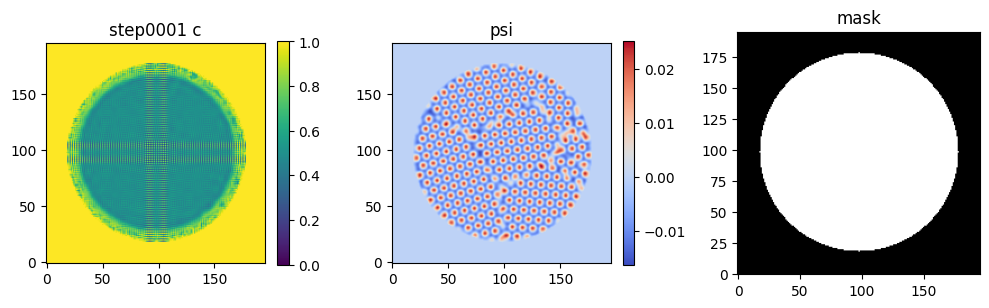

[step 0025] max|psi|=0.024, <c_in>=0.5815


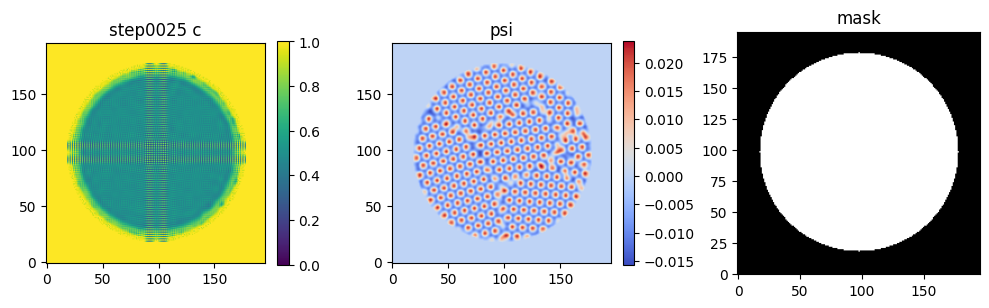

[step 0050] max|psi|=0.022, <c_in>=0.5862


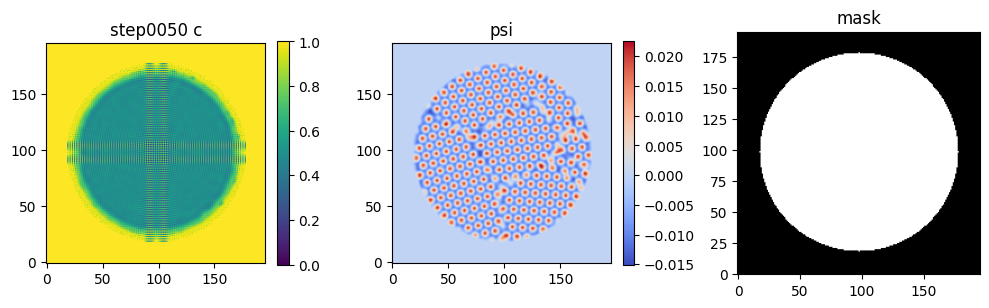

[step 0075] max|psi|=0.021, <c_in>=0.5897


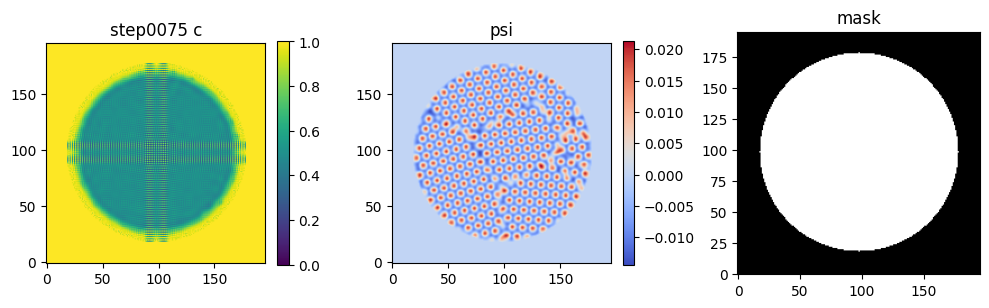

[step 0100] max|psi|=0.020, <c_in>=0.5926


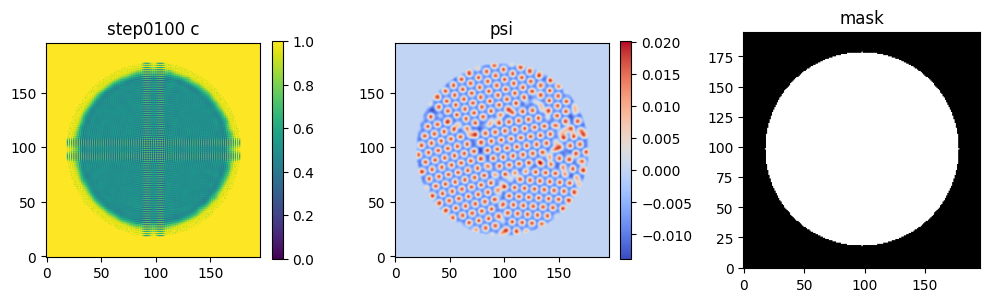

[step 0125] max|psi|=0.019, <c_in>=0.5950


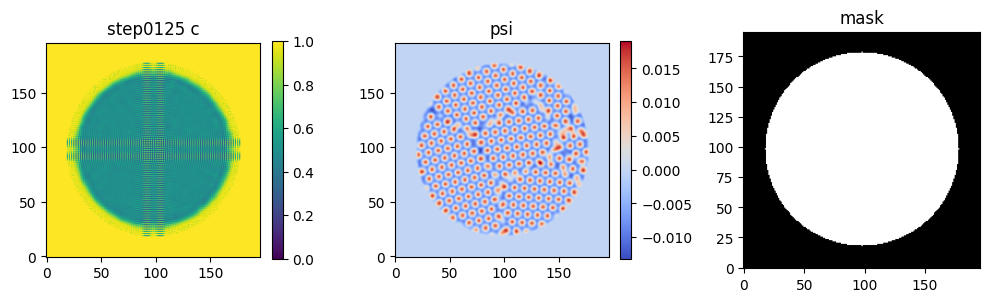

[step 0150] max|psi|=0.018, <c_in>=0.5972


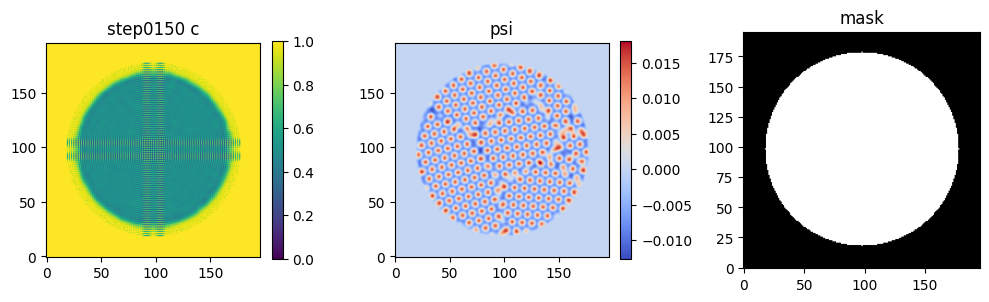

[step 0175] max|psi|=0.017, <c_in>=0.5992


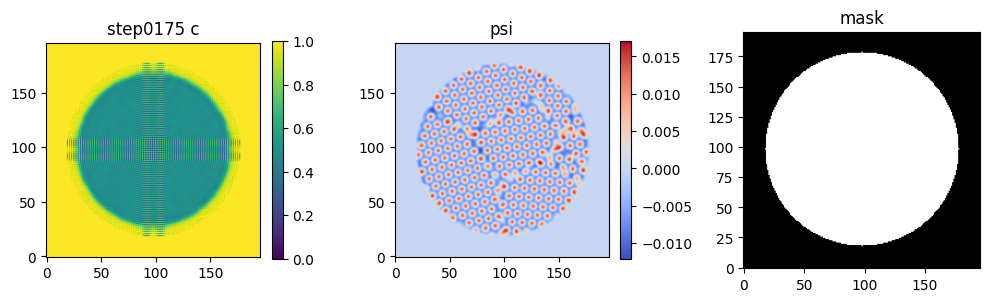

[step 0200] max|psi|=0.016, <c_in>=0.6010


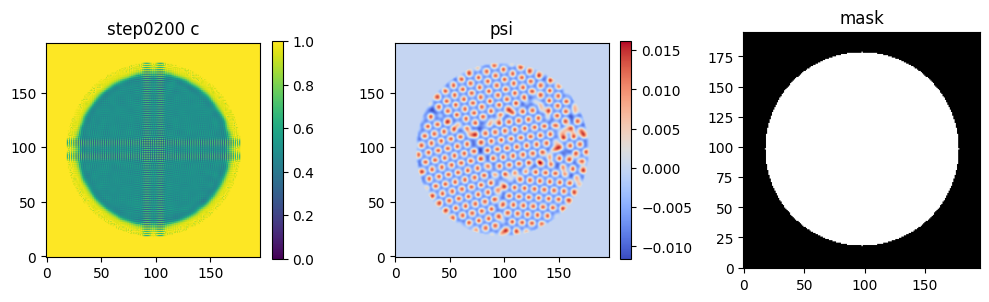

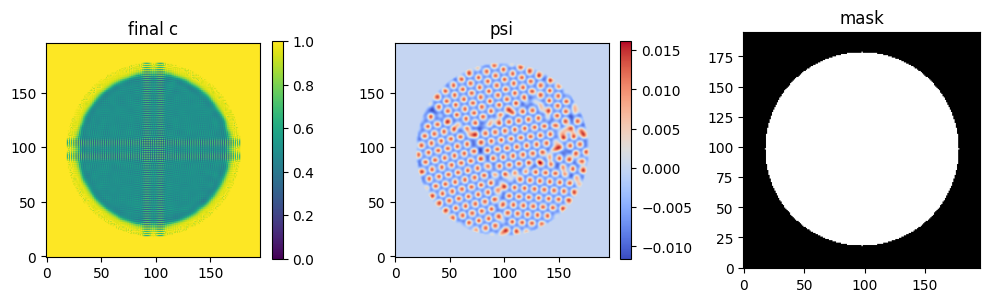

Time integration loop finished.


In [45]:
# Define the calculate_mobility function directly in the notebook (re-defining to be sure)
def calculate_mobility(c, psi, mask, mobility_base=1.0, mobility_grain_boundary=100.0):
    """Calculates a spatially varying mobility field.

    Args:
        c: The concentration field.
        psi: The phase field.
        mask: The mask defining the active region.
        mobility_base: The base mobility within grains.
        mobility_grain_boundary: The additional mobility at grain boundaries.

    Returns:
        A spatially varying mobility field M.
    """
    # Avoid division by zero if psi is all zeros within the mask
    psi_abs_max = np.abs(psi[mask]).max()
    psi_abs_max = psi_abs_max if psi_abs_max > 1e-9 else 1.0 # Use 1.0 if max is zero or very small

    # Calculate mobility. Ensure it's at least mobility_base
    M = mobility_base + mobility_grain_boundary * (1.0 - np.clip(np.abs(psi) / psi_abs_max, 0.0, 1.0))
    M[~mask] = 0.0  # Ensure zero mobility outside the masked region
    return M

# Define the ch_step_spectral function directly in the notebook (re-defining to be sure)
# This version includes the mobility_base and mobility_grain_boundary arguments
# and calls the calculate_mobility function defined above.
def ch_step_spectral(
    c, psi, p, cache, *, dt=1e-3, n_sub=1, mask=None,
    kappa_iso=None, mu_coupling=None, reservoir_value=1.0,
    mobility_base=1.0, mobility_grain_boundary=100.0 # Added mobility parameters
):
    c = np.asarray(c, dtype=np.float64, order='C').copy()
    if kappa_iso is None:
        kappa_iso = float(p.kappa)
    for _ in range(n_sub):
        mu = mu_chem_regular_solution(c, float(p.RT), float(p.Om)) # mu_chem_regular_solution is from a previous cell
        mu -= laplace_fft(c, cache) # laplace_fft is from a previous cell
        if callable(mu_coupling):
            mu += mu_coupling(c, psi)

        # Calculate the spatially varying mobility M
        M = calculate_mobility(c, psi, mask, mobility_base=mobility_base, mobility_grain_boundary=mobility_grain_boundary)

        # Use the spatially varying mobility M in the divergence term
        div_term = div_of_M_grad_mu_fft(M, mu, cache) # div_of_M_grad_mu_fft is from a previous cell

        K2 = cache.K2
        # Use M in the denominator where mobility is present
        # This assumes M is applied element-wise to K2 and K2**2
        Ak = 1.0 + dt * (M * K2 + kappa_iso * M * K2**2)

        rhs = c + dt * div_term
        # Ensure division is element-wise with Ak
        c = np.real(ifftn(fftn(rhs) / Ak))


        if mask is not None:
            c[~mask] = reservoir_value
        np.clip(c, 1e-8, 1.0 - 1e-8, out=c)
        if not np.isfinite(c).all():
            raise FloatingPointError('CH spectral step produced NaN/Inf; lower dt or mobility.')
    return c

# Define the pfc_step_spectral function directly in the notebook
# This version implements the spectral solver logic
def pfc_step_spectral(psi, c, r_field, p, cache, mask, dt, psi_clip=1.8):
    """Performs one spectral step for the PFC equation.

    Args:
        psi: The phase field.
        c: The concentration field.
        r_field: The spatially varying r parameter.
        p: The parameters object.
        cache: The FFTCache object.
        mask: The mask defining the active region.
        dt: The time step size.
        psi_clip: Value to clip psi to.

    Returns:
        The updated psi field.
    """
    # Ensure psi is float64 and C-contiguous
    psi = np.asarray(psi, dtype=np.float64, order='C').copy()

    # Transform psi to Fourier space
    psik = fftn(psi)

    # Calculate the right-hand side in Fourier space
    # PFC equation: d(psi)/dt = (r - (1-q^2)^2) psi - psi^3
    # In Fourier space: d(psik)/dt = fft(r*psi) - (1+K2)**2 * psik - fft(psi^3)

    psi_cubed = psi**3
    psi_cubed_k = fftn(psi_cubed)

    # r_field is spatially varying, so r*psi needs to be calculated in real space and then FFT'd
    r_psi_k = fftn(r_field * psi)

    spectral_operator = (1.0 + cache.K2)**2

    # Linear term in Fourier space: fft(r*psi) - (1+K2)**2 * psik
    linear_term_k = r_psi_k - spectral_operator * psik

    # Nonlinear term in Fourier space: -fft(psi^3)
    nonlinear_term_k = -psi_cubed_k

    # Forward Euler time integration in Fourier space
    psik_new = psik + dt * (linear_term_k + nonlinear_term_k)

    # Transform back to real space
    psi_new = np.real(ifftn(psik_new))

    # Apply mask and clipping
    if mask is not None:
        psi_new[~mask] = 0.0 # Set to zero outside the mask

    # Apply clipping
    np.clip(psi_new, -psi_clip, psi_clip, out=psi_new)

    # Optional: Handle enforce_amorphous if needed. This is complex in spectral space.
    # For this subtask, we will skip the enforce_amorphous logic in the spectral step.

    if not np.isfinite(psi_new).all():
        raise FloatingPointError('PFC spectral step produced NaN/Inf; lower dt.')

    return psi_new


# Define mobility_base and mobility_grain_boundary
mobility_base = 1.0
mobility_grain_boundary = 1.0

# Define the time step for the spectral PFC solver
pfc_spectral_dt = 1e-3 # Choose a suitable time step for the spectral solver

# --- Time integration (outer loop): ψ relax + spectral CH ---
n_outer   = 200
# pfc_steps = 800 # Not needed for spectral step
ch_dt     = 1e-3
ch_sub    = 5
save_every = 25
snapshots = []

print("Starting time integration loop with locally defined spectral PFC step...")

for n in range(1, n_outer+1):
    # 1) spectral psi step at current c
    # Call the locally defined pfc_step_spectral function
    psi = pfc_step_spectral(psi=psi, c=c, r_field=r_field, p=p, cache=fft_cache,
                                  mask=mask, dt=pfc_spectral_dt, psi_clip=1.8) # Pass necessary args, remove others


    # 2) CH update (spectral, semi-implicit)
    # Call the locally defined ch_step_spectral with the correct arguments
    c = ch_step_spectral(c=c, psi=psi, p=p, cache=fft_cache, dt=ch_dt, n_sub=ch_sub,
                         mask=mask, kappa_iso=p.kappa,
                         mu_coupling=None, reservoir_value=1.0,
                         mobility_base=mobility_base, mobility_grain_boundary=mobility_grain_boundary)


    # Diagnostics & snapshots
    if n % save_every == 0 or n in (1, n_outer):
        print(f"[step {n:04d}] max|psi|={np.abs(psi[mask]).max():.3f}, <c_in>={c[mask].mean():.4f}")
        snapshots.append((n, c.copy(), psi.copy()))
        # plot_fields should be available from a previous cell
        plot_fields(c, psi, mask, title_prefix='step'+str(n).zfill(4))
        plt.show()

# Plot final fields
# plot_fields should be available from a previous cell
plot_fields(c, psi, mask, title_prefix='final')
plt.show()

print("Time integration loop finished.")
